In [227]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
air_df = pd.read_csv('Airdata.csv')
air_df.head()

,DateTime,Temperature,Humidity,Wind_Speed,Wind_Direction,NO2_Location_A,NO2_Location_B,NO2_Location_C
0,1/1/2020 0:00,2.180529,87,1.484318,75.963760,39.23,52.88,62.37
1,1/1/2020 1:00,1.490529,89,2.741678,113.198590,38.30,44.95,52.53
2,1/1/2020 2:00,1.690529,85,3.563818,135.000000,NaN,48.40,54.80
3,1/1/2020 3:00,1.430529,84,2.811690,129.805570,37.28,47.18,50.80
4,1/1/2020 4:00,0.840529,86,1.800000,126.869896,29.97,41.48,54.43


In [4]:
air_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   DateTime        8784 non-null   object 
 1   Temperature     8784 non-null   float64
 2   Humidity        8784 non-null   int64  
 3   Wind_Speed      8784 non-null   float64
 4   Wind_Direction  8784 non-null   float64
 5   NO2_Location_A  8664 non-null   float64
 6   NO2_Location_B  8204 non-null   float64
 7   NO2_Location_C  8652 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 549.1+ KB


In [5]:
print('Number of missing values:')
for col in air_df.columns:
    n_MV = sum(air_df[col].isna())
    print('{}:{}'.format(col,n_MV))

Number of missing values:
DateTime:0
Temperature:0
Humidity:0
Wind_Speed:0
Wind_Direction:0
NO2_Location_A:120
NO2_Location_B:580
NO2_Location_C:132


### Diagnosing missing values

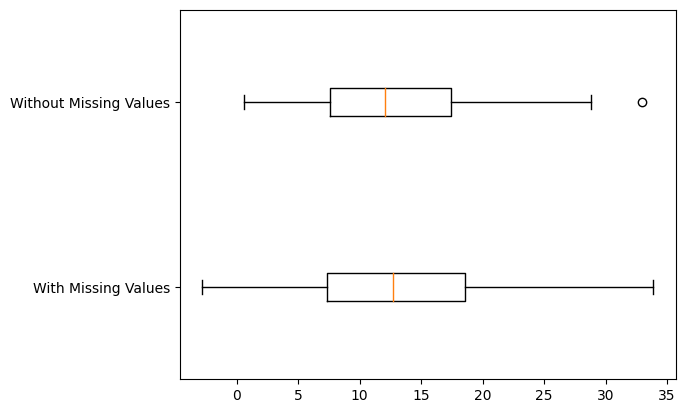

In [6]:
# Diagnosing missing values in NO2_Location_A field based on temperature
BM_MV = air_df.NO2_Location_A.isna()
MV_Labels = ['With Missing Values','Without Missing Values']

box_sr = pd.Series('',index = BM_MV.unique())

for poss in BM_MV.unique():
    BM = BM_MV == poss
    box_sr[poss] = air_df[BM]['Temperature']
    
plt.boxplot(box_sr, vert=False)
plt.yticks([1,2], MV_Labels)
plt.show()
# no significant change in the Temperature value between the 2 populations
# this shows that a change in Temp could not have caused or influenced the occurrence
# of missing values under NO2_Location_A field

In [7]:
pd.Series('',index = BM_MV.unique())

False    
True     
dtype: object

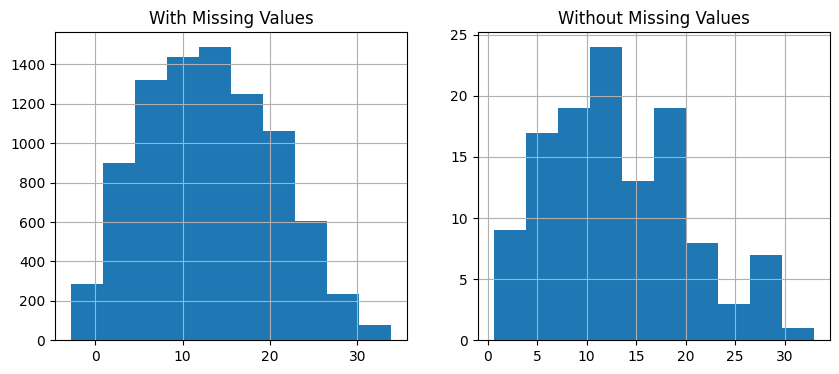

In [8]:
BM_MV = air_df.NO2_Location_A.isna()
temp_range = (air_df['Temperature'].min(), air_df['Temperature'].max())
MV_labels = ['With Missing Values','Without Missing Values']

plt.figure(figsize=(10,4))

for i, poss in enumerate(BM_MV.unique()):
    plt.subplot(1,2,i+1)
    BM = BM_MV == poss
    air_df[BM]['Temperature'].hist()
    plt.xlim = temp_range
    plt.title(MV_labels[i])
plt.show()
# no significant change in the Temperature value between the 2 populations
# this shows that a change in Temp could not have caused or influenced the occurrence
# of missing values under NO2_Location_A

### Perform TTest of independence

In [9]:
# Use ttest_ind to test whether the temperature field is meaningfully different between the 2 groups
from scipy.stats import ttest_ind
BM_MV = air_df.NO2_Location_A.isna()
ttest_ind(air_df[BM_MV]['Temperature'], air_df[~BM_MV]['Temperature'])
# the high p-value show there is no meaningful association with the missing values in NO2_Location_A
# affecting the Temperature attribute

TtestResult(statistic=0.05646499065315542, pvalue=0.9549726689684548, df=8782.0)

In [10]:
air_df.NO2_Location_A.isna().head(5)

0    False
1    False
2     True
3    False
4    False
Name: NO2_Location_A, dtype: bool

In [11]:
# the tilde sign looks for the "false" values
air_df[~BM_MV]['Temperature'].head(5)

0    2.180529
1    1.490529
3    1.430529
4    0.840529
5    1.160529
Name: Temperature, dtype: float64

In [12]:
air_df[BM_MV]['Temperature'].head(5)

2     1.690529
7     1.700529
25    3.020529
71    7.530528
75    8.070529
Name: Temperature, dtype: float64

In [15]:
# Create a function for multivariate numerical fields to diagnose missing values
# based on numerical attributes to tell whether the attribute impacts attribute containing missing values

# This creates the boxplot, histogram, and ttest_ind for each numerical attribute

from scipy.stats import ttest_ind
def Diagnose_MV_Numerical(df, str_att_name, BM_MV):
    MV_labels = {True:'With Missing Values',False:'Without Missing Values'}
    
    labels=[]
    box_sr = pd.Series('',index=BM_MV.unique())
    for poss in BM_MV.unique():
        BM = BM_MV == poss
        box_sr[poss] = df[BM][str_att_name].dropna()
        labels.append(MV_labels[poss])
    
    plt.boxplot(box_sr,vert=False)
    plt.yticks([1,2],labels)
    plt.xlabel(str_att_name)
    plt.show()
    
    plt.figure(figsize=(10,4))
        
    att_range = (df[str_att_name].min(), df[str_att_name].max())
    
    for i, poss in enumerate(BM_MV.unique()):
        plt.subplot(1,2,i+1)
        BM = BM_MV == poss
        df[BM][str_att_name].hist()
        plt.xlim = att_range
        plt.xlabel(str_att_name)
        plt.title(MV_labels[poss])
    plt.show()

    group_1_date = df[BM_MV][str_att_name].dropna()
    group_2_date = df[~BM_MV][str_att_name].dropna()

    p_value = ttest_ind(group_1_date, group_2_date).pvalue

    print('p-value of t-test: {}'.format(p_value))

Diagnosis Analysis of Missing Values for Temperature:


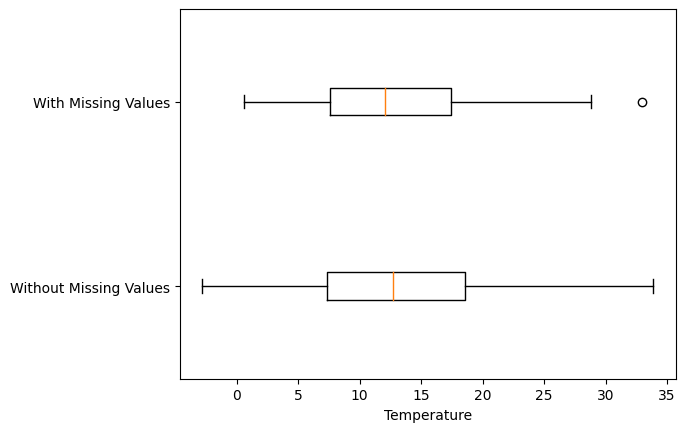

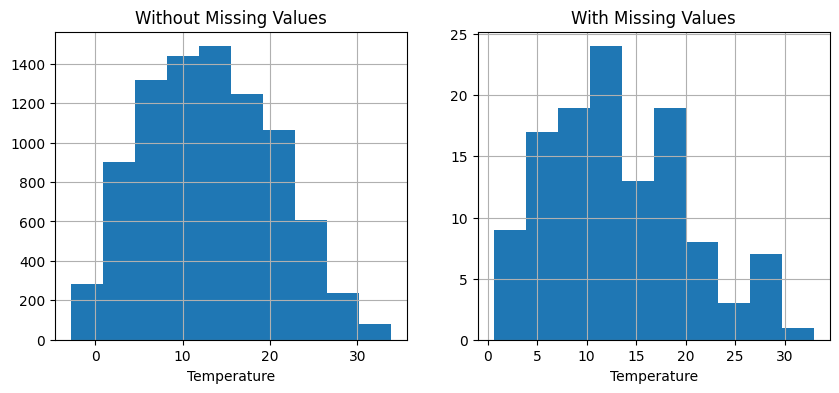

p-value of t-test: 0.9549726689684548
- - - - - - - - - - - - - divider - - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for Humidity:


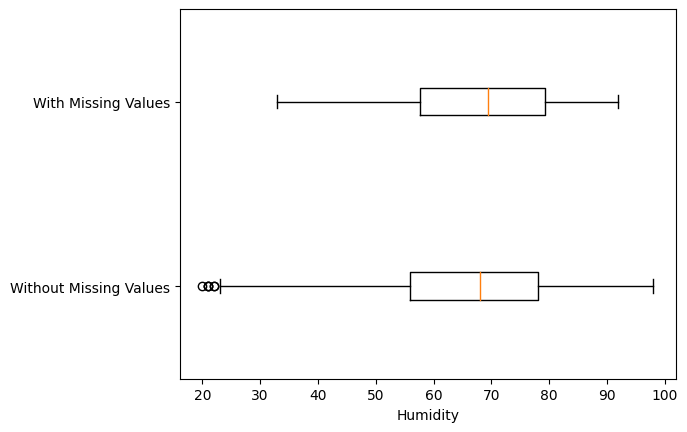

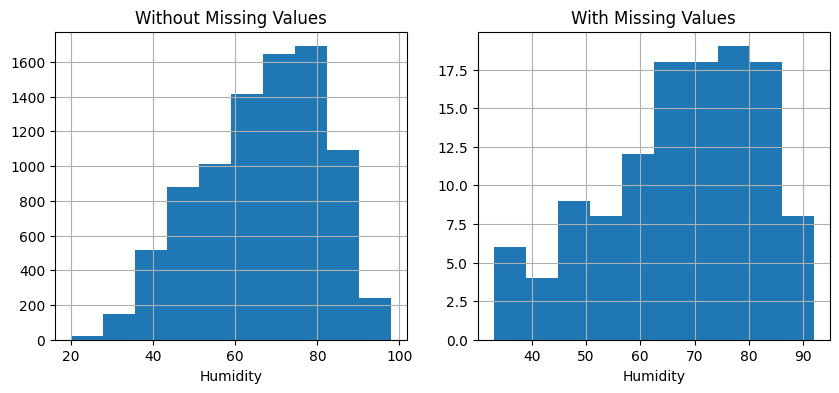

p-value of t-test: 0.5593319830352679
- - - - - - - - - - - - - divider - - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for Wind_Speed:


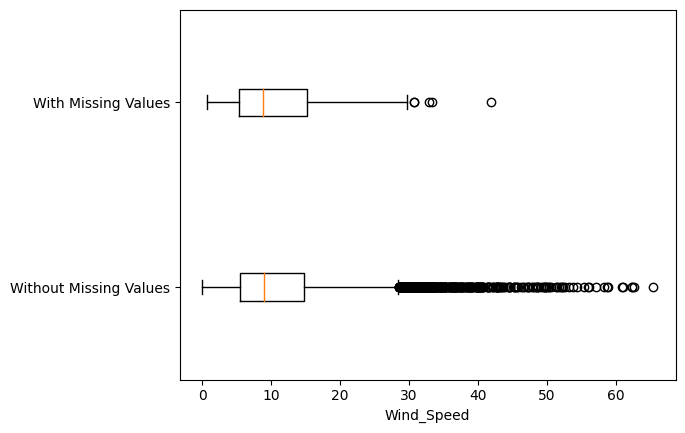

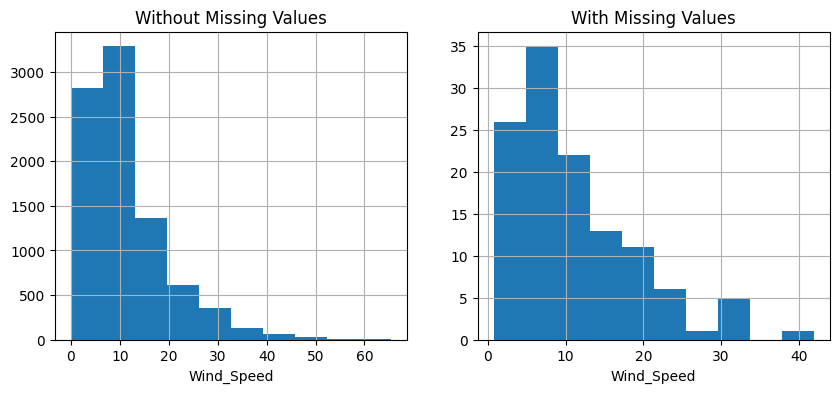

p-value of t-test: 0.8172472856083665
- - - - - - - - - - - - - divider - - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for Wind_Direction:


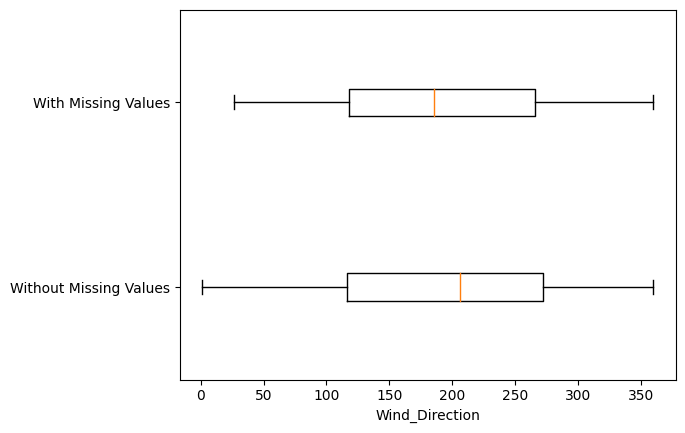

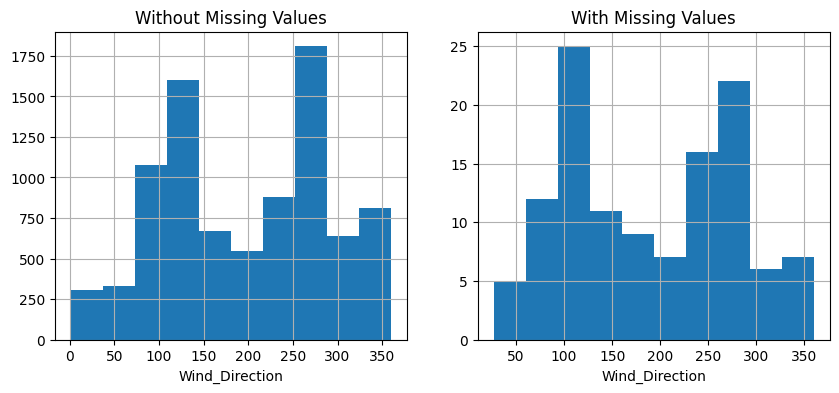

p-value of t-test: 0.39869195396670654
- - - - - - - - - - - - - divider - - - - - - - - - - - - 


In [16]:
numerical_attributes = ['Temperature','Humidity','Wind_Speed','Wind_Direction']
BM_MV = air_df['NO2_Location_A'].isna()
for att in numerical_attributes:
    print('Diagnosis Analysis of Missing Values for {}:'.format(att))
    Diagnose_MV_Numerical(air_df, att, BM_MV)
    print('- - - - - - - - - - - - - divider - - - - - - - - - - - - ')

# None of the numerical fields appears to impact the missing values of the NO2_Location_A field
# None of the p-values are less than 0.05 which would indicate an impacting numerical attribute

In [46]:
air_df.head()

,DateTime,Temperature,Humidity,Wind_Speed,Wind_Direction,NO2_Location_A,NO2_Location_B,NO2_Location_C
0,1/1/2020 0:00,2.180529,87,1.484318,75.963760,39.23,52.88,62.37
1,1/1/2020 1:00,1.490529,89,2.741678,113.198590,38.30,44.95,52.53
2,1/1/2020 2:00,1.690529,85,3.563818,135.000000,NaN,48.40,54.80
3,1/1/2020 3:00,1.430529,84,2.811690,129.805570,37.28,47.18,50.80
4,1/1/2020 4:00,0.840529,86,1.800000,126.869896,29.97,41.48,54.43


### Diagnose missing values based on categorical attributes

In [17]:
air_df['DateTime'] = pd.to_datetime(air_df.DateTime)

In [18]:
air_df['month'] = air_df.DateTime.dt.month
air_df['day'] = air_df.DateTime.dt.day
air_df['hour'] = air_df.DateTime.dt.hour
air_df['weekday'] = air_df.DateTime.dt.day_name()

In [19]:
air_df.head()

,DateTime,Temperature,Humidity,Wind_Speed,Wind_Direction,NO2_Location_A,NO2_Location_B,NO2_Location_C,month,day,hour,weekday
0,2020-01-01 00:00:00,2.180529,87,1.484318,75.963760,39.23,52.88,62.37,1,1,0,Wednesday
1,2020-01-01 01:00:00,1.490529,89,2.741678,113.198590,38.30,44.95,52.53,1,1,1,Wednesday
2,2020-01-01 02:00:00,1.690529,85,3.563818,135.000000,NaN,48.40,54.80,1,1,2,Wednesday
3,2020-01-01 03:00:00,1.430529,84,2.811690,129.805570,37.28,47.18,50.80,1,1,3,Wednesday
4,2020-01-01 04:00:00,0.840529,86,1.800000,126.869896,29.97,41.48,54.43,1,1,4,Wednesday


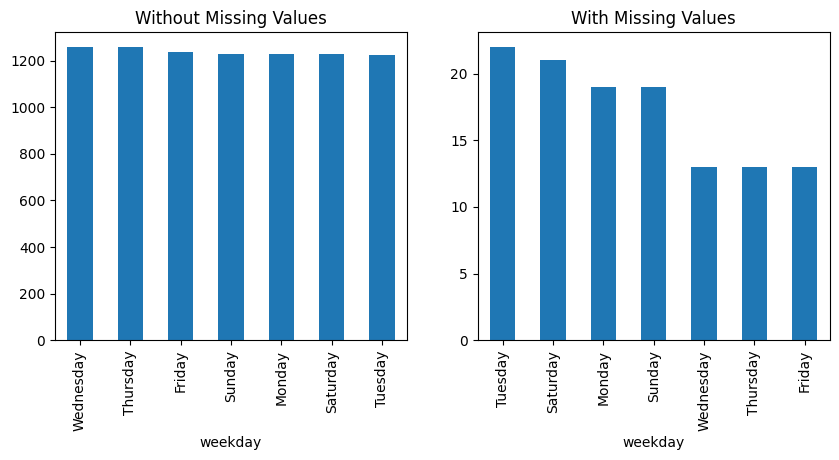

In [20]:
# Create bar chart showing impact of missing values on the day of the week
# There appears to be no impact

BM_MV = air_df.NO2_Location_A.isna()
MV_labels = ['Without Missing Values', 'With Missing Values']

plt.figure(figsize=(10,4))
for i, poss in enumerate(BM_MV.unique()):
    plt.subplot(1,2,i+1)
    BM = BM_MV == poss
    air_df[BM].weekday.value_counts().plot.bar()
    plt.title(MV_labels[i])
plt.show()

In [22]:
# build a contingency table in order to run the chi-squared independence test
from scipy.stats import chi2_contingency
BM_MV = air_df['NO2_Location_A'].isna()
contingency_table = pd.crosstab(BM_MV, air_df.weekday)
contingency_table

weekday,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
NO2_Location_A,,,,,,,
False,1235,1229,1227,1229,1259,1226,1259
True,13,19,21,19,13,22,13


In [23]:
# Perform the chi-squared contingency test
# The p-value of 0.4177 indicates there is not a relationship between the weekday and 
# the missing values of NO2_Location_A
chi2_contingency(contingency_table)

Chi2ContingencyResult(statistic=6.048964133655503, pvalue=0.41772751510388023, dof=6, expected_freq=array([[1230.95081967, 1230.95081967, 1230.95081967, 1230.95081967,
        1254.62295082, 1230.95081967, 1254.62295082],
       [  17.04918033,   17.04918033,   17.04918033,   17.04918033,
          17.37704918,   17.04918033,   17.37704918]]))

In [32]:
# Create a function for multivariate categorical fields to diagnose missing values
# based on categorical attributes to tell whether the attribute impacts attribute containing missing values

# This creates the barplot and chi2_contingency for each categorical attribute

from scipy.stats import chi2_contingency

def Diagnose_MV_Categorical(df, str_att_name, BM_MV):
    MV_labels = {True:'With Missing Values',
                 False: 'Without Missing Values'}
    plt.figure(figsize=(10,4))
    for i, poss in enumerate(BM_MV.unique()):
        plt.subplot(1,2,i+1)
        BM = BM_MV == poss
        df[BM][str_att_name].value_counts().plot.bar()
        plt.title(MV_labels[poss])
    plt.show()
    contingency_table = pd.crosstab(BM_MV, df[str_att_name])
    p_value = chi2_contingency(contingency_table)[1]
    print('P-value of Chi_squared test: {}'.format(p_value))
    if p_value < 0.05:
        print(f'{att.capitalize()} is influencing the tendency of missing values')
    else:
        print(f'{att.capitalize()} is not influencing the tendency of missing values')

Diagnosis Analysis for month:


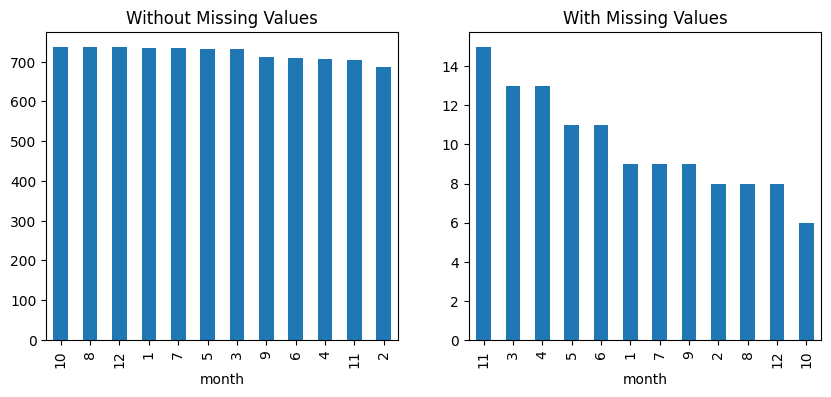

P-value of Chi_squared test: 0.709656583292986
Month is not influencing the tendency of missing values
- - - - - - - - - - divider - - - - - - - - -
Diagnosis Analysis for day:


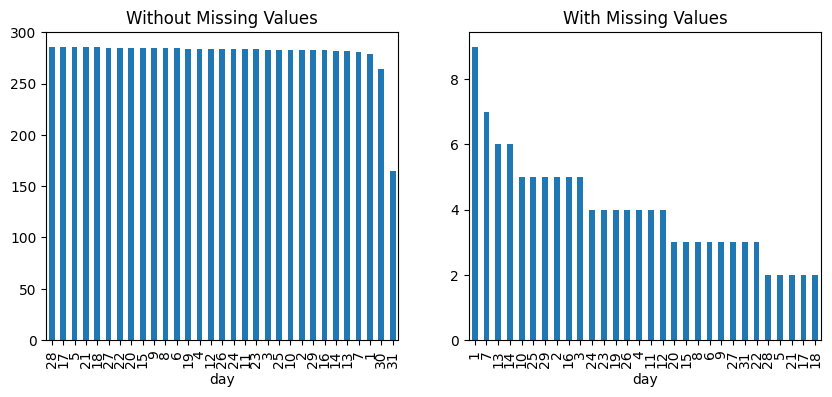

P-value of Chi_squared test: 0.8040640724986007
Day is not influencing the tendency of missing values
- - - - - - - - - - divider - - - - - - - - -
Diagnosis Analysis for hour:


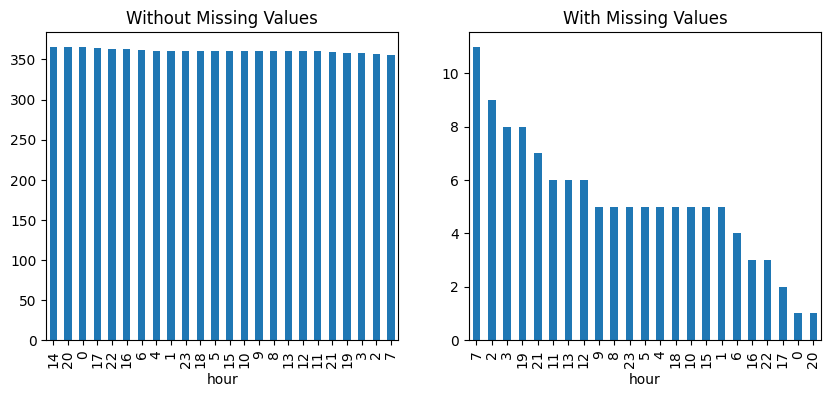

P-value of Chi_squared test: 0.12725321642668141
Hour is not influencing the tendency of missing values
- - - - - - - - - - divider - - - - - - - - -
Diagnosis Analysis for weekday:


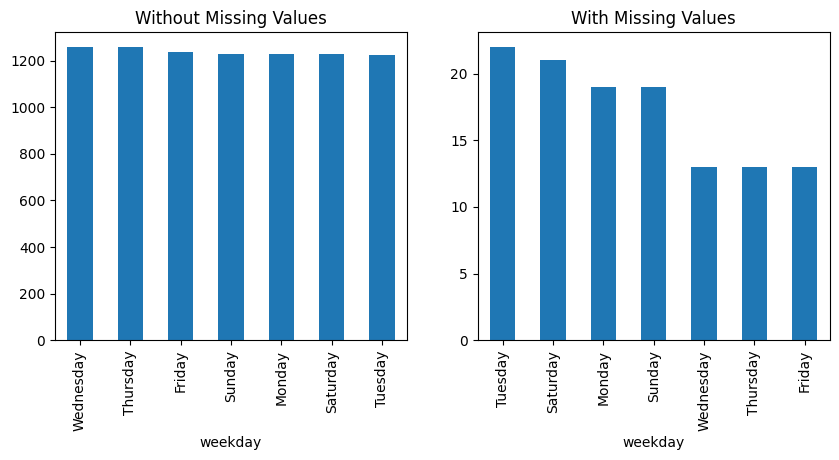

P-value of Chi_squared test: 0.41772751510388023
Weekday is not influencing the tendency of missing values
- - - - - - - - - - divider - - - - - - - - -


In [33]:
categorical_attributes = ['month','day','hour','weekday']
BM_MV = air_df.NO2_Location_A.isna()
for att in categorical_attributes:
    print('Diagnosis Analysis for {}:'.format(att))
    Diagnose_MV_Categorical(air_df, att, BM_MV)
    print('- - - - - - - - - - divider - - - - - - - - -')

### Diagnosing missing values in NO2_Location_B

Diagnosis Analysis for Temperature:


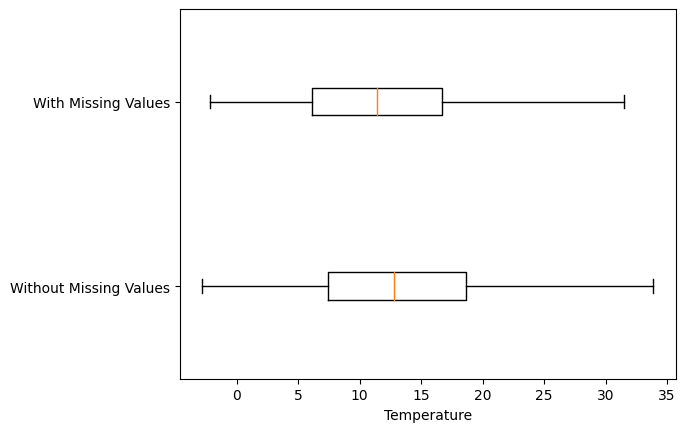

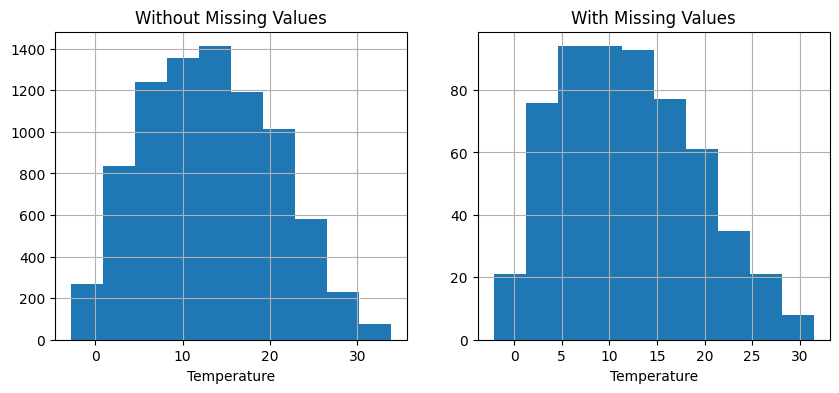

p-value of t-test: 0.00018958810621204928
- - - - - - - - - - divider - - - - - - - - -
Diagnosis Analysis for Humidity:


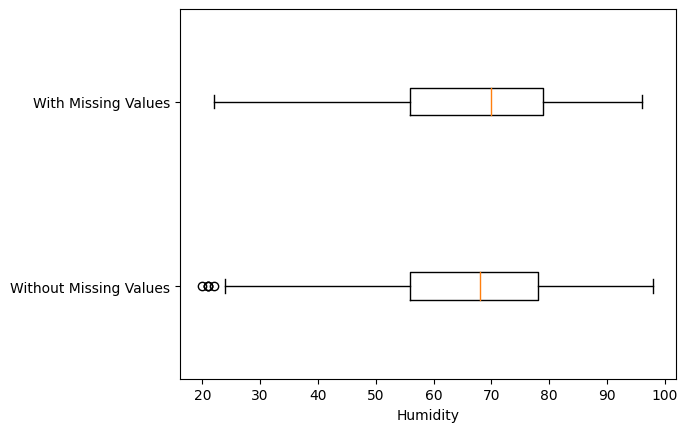

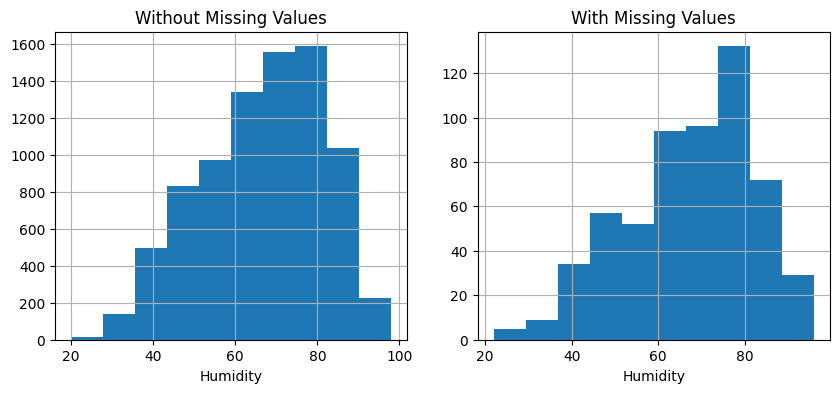

p-value of t-test: 0.43891454332709956
- - - - - - - - - - divider - - - - - - - - -
Diagnosis Analysis for Wind_Speed:


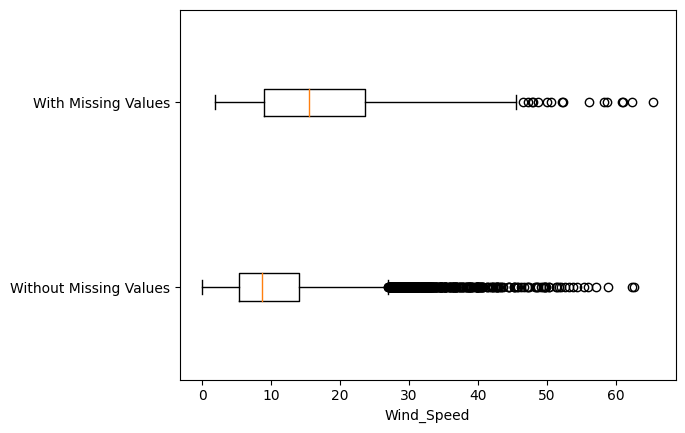

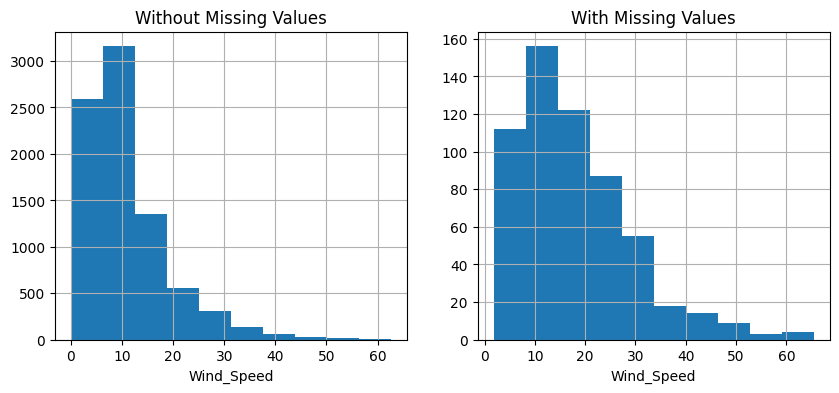

p-value of t-test: 1.3126894108159327e-85
- - - - - - - - - - divider - - - - - - - - -
Diagnosis Analysis for Wind_Direction:


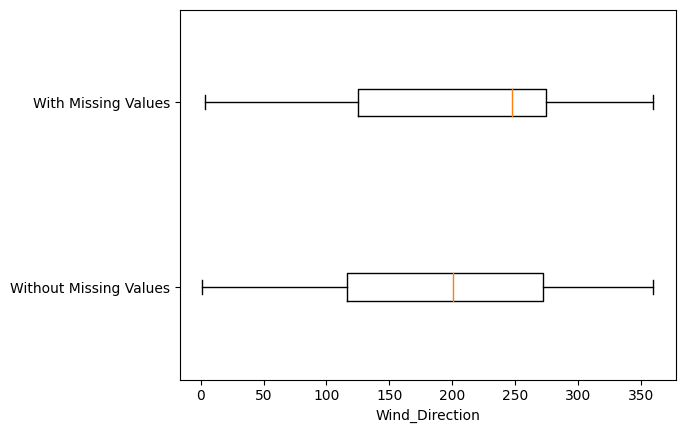

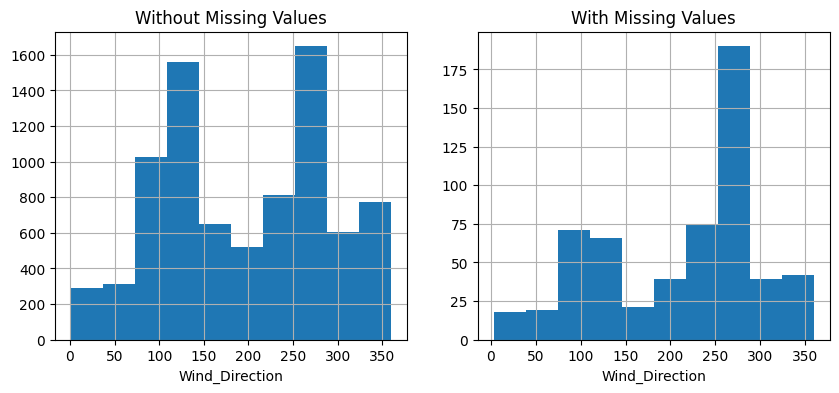

p-value of t-test: 5.8398056632254833e-05
- - - - - - - - - - divider - - - - - - - - -
Diagnosis Analysis for month:


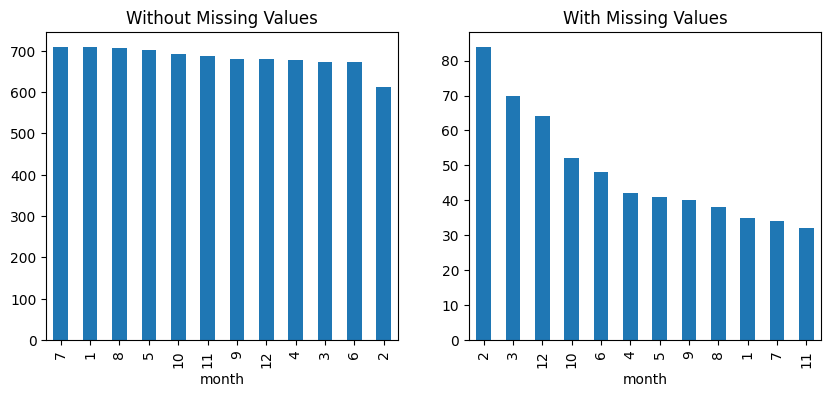

P-value of Chi_squared test: 1.8048364819875927e-10
Month is influencing the tendency of missing values
- - - - - - - - - - divider - - - - - - - - -
Diagnosis Analysis for day:


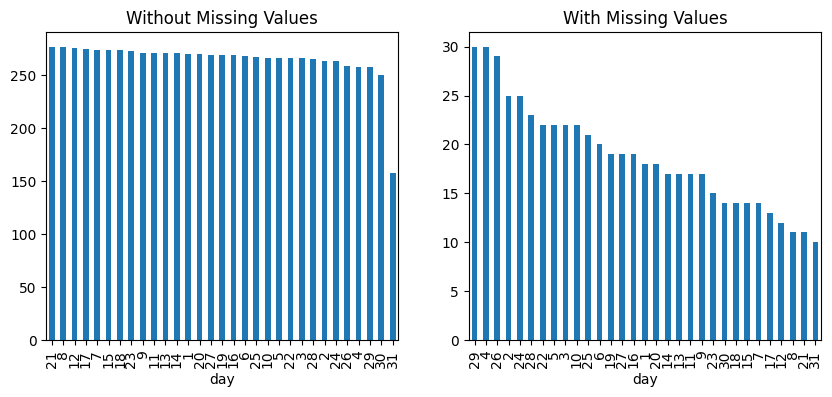

P-value of Chi_squared test: 0.03481669141156423
Day is influencing the tendency of missing values
- - - - - - - - - - divider - - - - - - - - -
Diagnosis Analysis for hour:


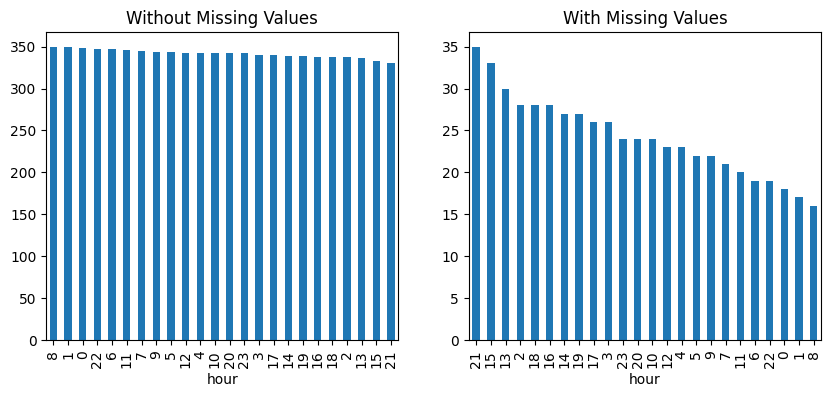

P-value of Chi_squared test: 0.3949474320151338
Hour is not influencing the tendency of missing values
- - - - - - - - - - divider - - - - - - - - -
Diagnosis Analysis for weekday:


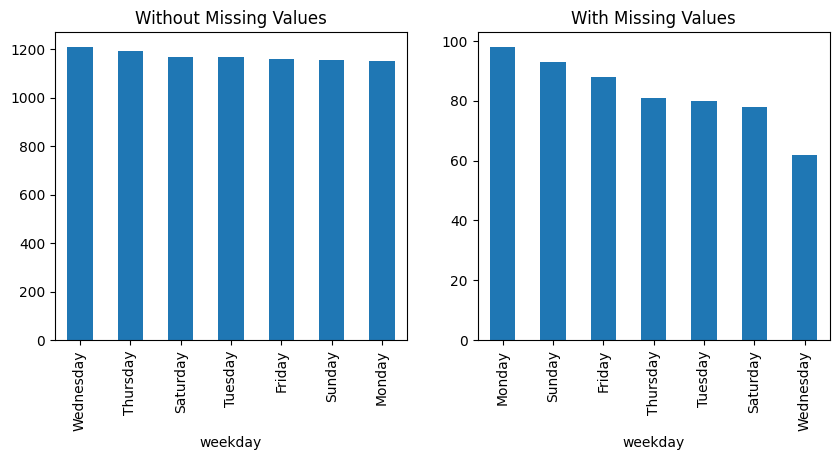

P-value of Chi_squared test: 0.07073083108612685
Weekday is not influencing the tendency of missing values
- - - - - - - - - - divider - - - - - - - - -


In [36]:
# There is a relationship between NO2_Location_B missing values and temperature, wind speed, wind direction, and month
# run a heatmap between the relationship fields to look for any relationships
categorical_attributes = ['month','day','hour','weekday']
numerical_attributes = ['Temperature','Humidity','Wind_Speed','Wind_Direction']
BM_MV = air_df["NO2_Location_B"].isna()

for att in numerical_attributes:
    print('Diagnosis Analysis for {}:'.format(att))
    Diagnose_MV_Numerical(air_df, att, BM_MV)
    print('- - - - - - - - - - divider - - - - - - - - -')
    
for att in categorical_attributes:
    print('Diagnosis Analysis for {}:'.format(att))
    Diagnose_MV_Categorical(air_df, att, BM_MV)
    print('- - - - - - - - - - divider - - - - - - - - -')

### Diagnosing missing values in NO3_Location_C

Diagnosis Analysis for Temperature:


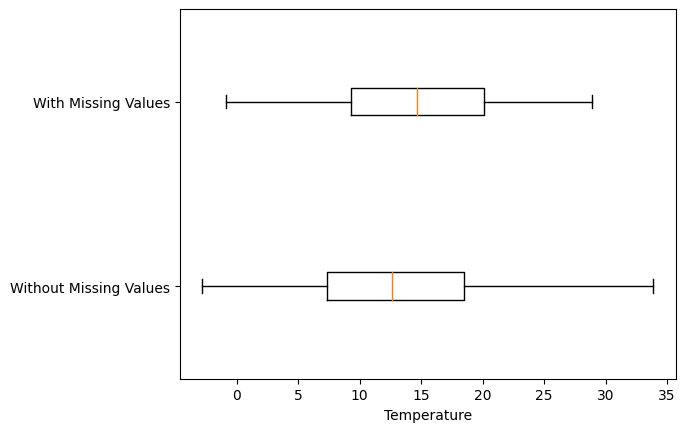

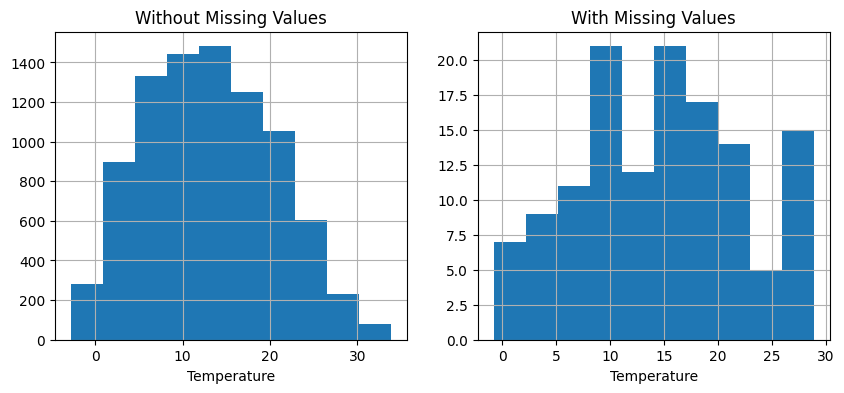

p-value of t-test: 0.01981913552818646
- - - - - - - - - - divider - - - - - - - - -
Diagnosis Analysis for Humidity:


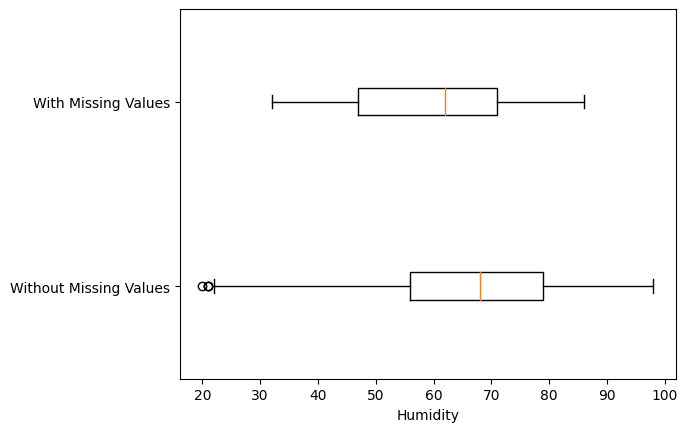

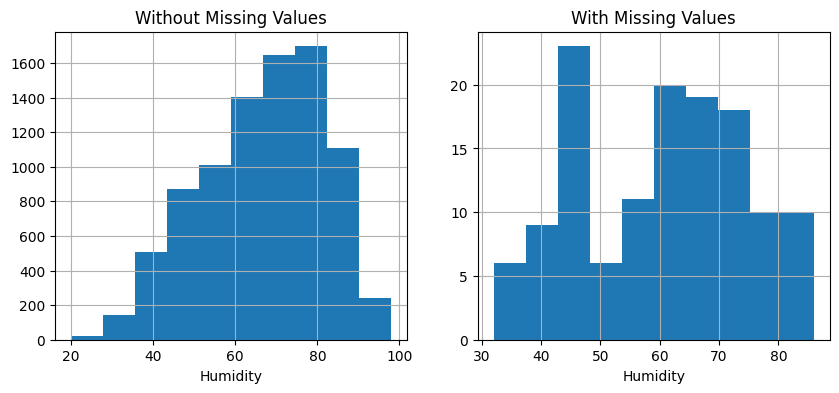

p-value of t-test: 8.179400599849167e-07
- - - - - - - - - - divider - - - - - - - - -
Diagnosis Analysis for Wind_Speed:


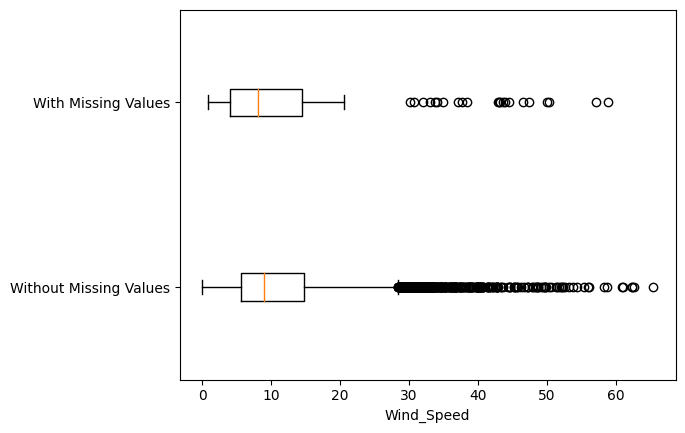

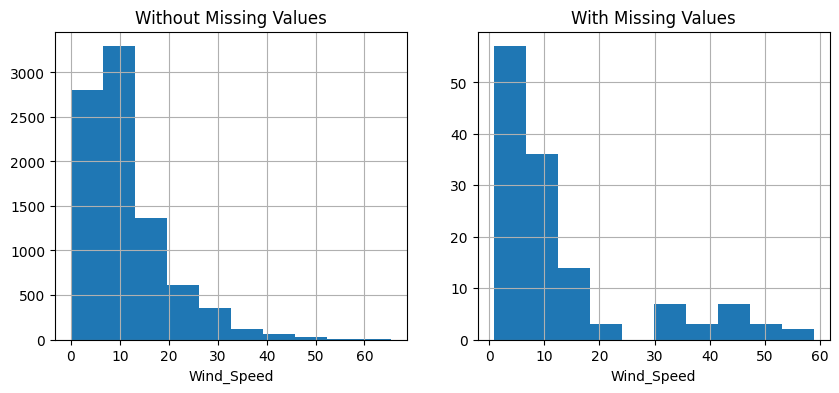

p-value of t-test: 0.013597962538292619
- - - - - - - - - - divider - - - - - - - - -
Diagnosis Analysis for Wind_Direction:


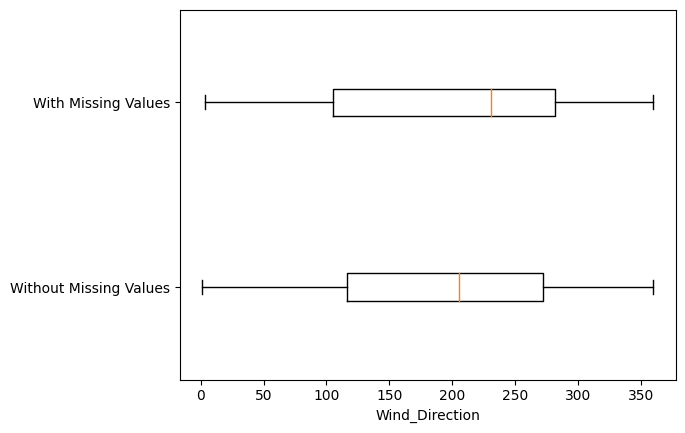

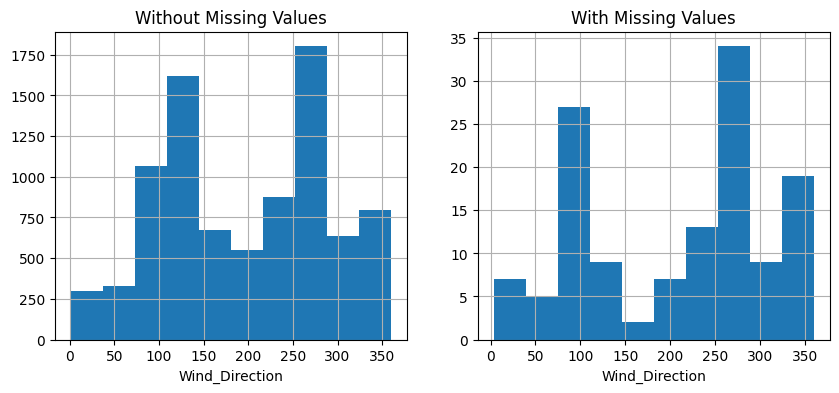

p-value of t-test: 0.3083081973623661
- - - - - - - - - - divider - - - - - - - - -
Diagnosis Analysis for month:


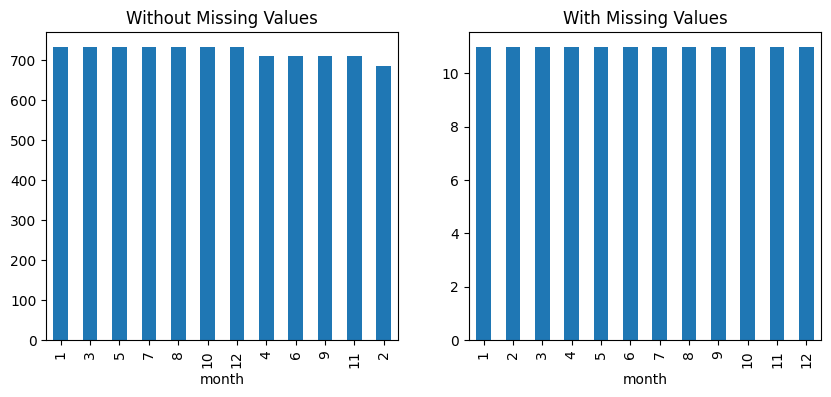

P-value of Chi_squared test: 0.9999999999839941
Month is not influencing the tendency of missing values
- - - - - - - - - - divider - - - - - - - - -
Diagnosis Analysis for day:


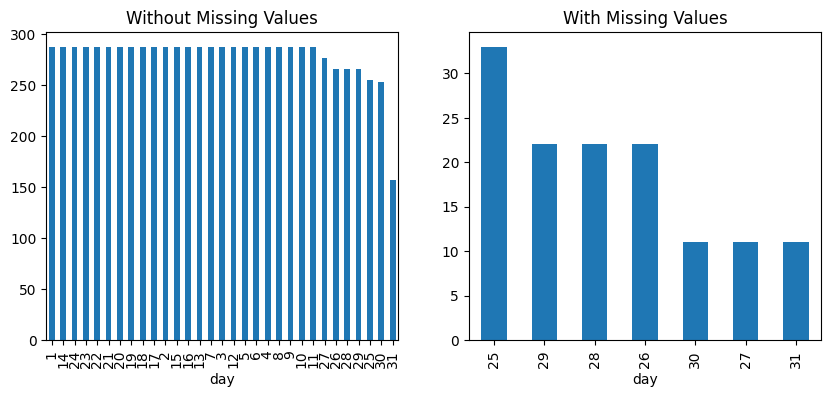

P-value of Chi_squared test: 4.5607973056357013e-101
Day is influencing the tendency of missing values
- - - - - - - - - - divider - - - - - - - - -
Diagnosis Analysis for hour:


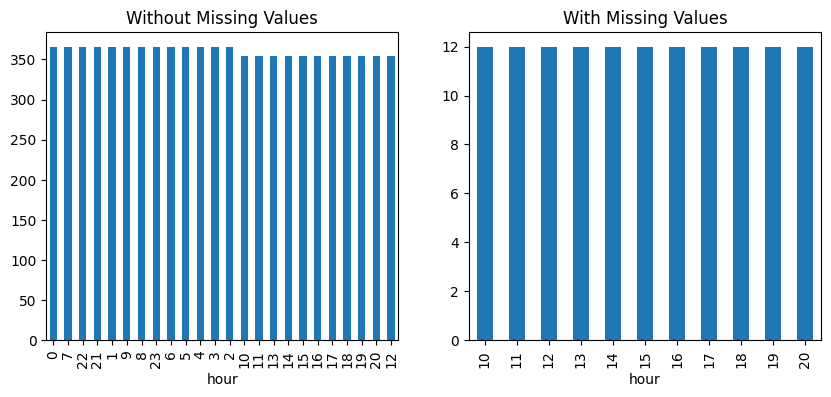

P-value of Chi_squared test: 3.3850851028854862e-22
Hour is influencing the tendency of missing values
- - - - - - - - - - divider - - - - - - - - -
Diagnosis Analysis for weekday:


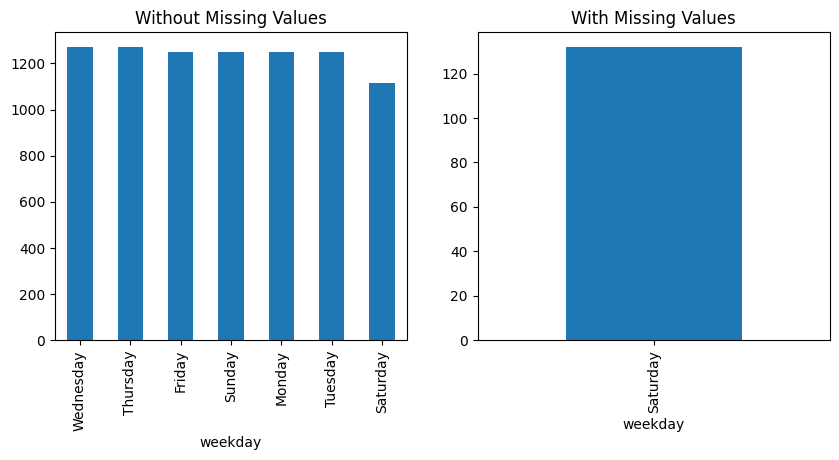

P-value of Chi_squared test: 1.554165460861991e-171
Weekday is influencing the tendency of missing values
- - - - - - - - - - divider - - - - - - - - -


In [37]:
# There is a relationship between NO2_Location_B missing values and temperature, humidity wind speed, day, hour, weekday
# Saturday is a strong relationship
# run a heatmap between the relationship fields to look for any relationships
categorical_attributes = ['month','day','hour','weekday']
numerical_attributes = ['Temperature','Humidity','Wind_Speed','Wind_Direction']
BM_MV = air_df["NO2_Location_C"].isna()

for att in numerical_attributes:
    print('Diagnosis Analysis for {}:'.format(att))
    Diagnose_MV_Numerical(air_df, att, BM_MV)
    print('- - - - - - - - - - divider - - - - - - - - -')
    
for att in categorical_attributes:
    print('Diagnosis Analysis for {}:'.format(att))
    Diagnose_MV_Categorical(air_df, att, BM_MV)
    print('- - - - - - - - - - divider - - - - - - - - -')

### Dealing with missing values

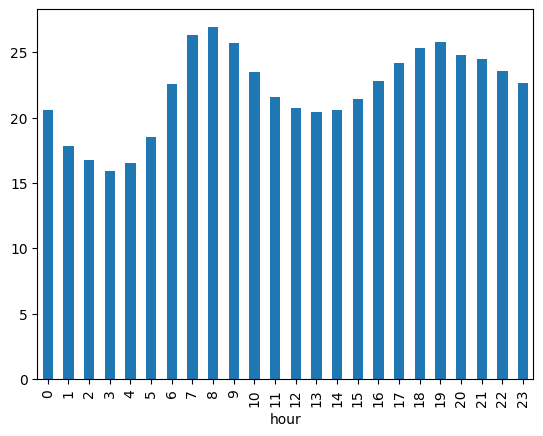

In [39]:
# Mean aggregation for MCAR missing values with small number of missing records
air_df.groupby('hour').NO2_Location_A.mean().plot.bar()
plt.show()

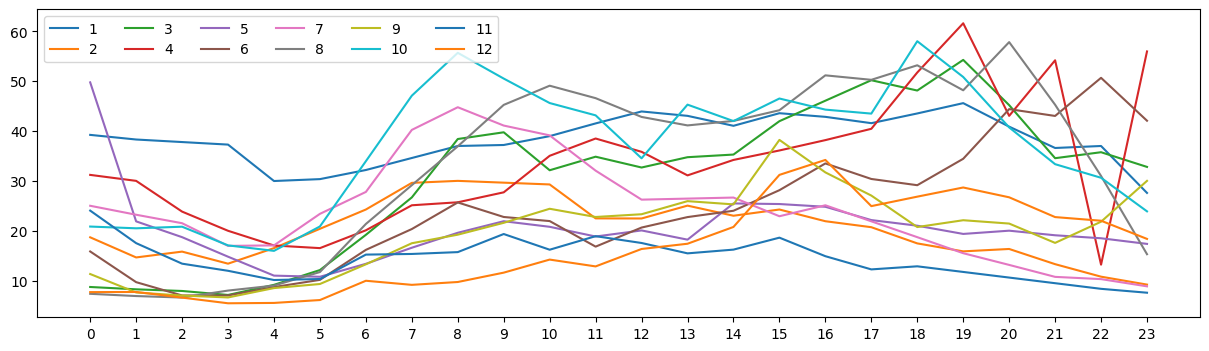

In [40]:
# Use interpolation for MCAR missing data that is for a time series
NO2_Location_A_noMV = air_df['NO2_Location_A'].interpolate(method='linear')
month_poss = air_df['month'].unique()
hour_poss = air_df['hour'].unique()
plt.figure(figsize=(15,4))
for mn in month_poss:
    BM = (air_df['month'] == mn) & (air_df['day'] == 1)
    plt.plot(NO2_Location_A_noMV[BM].values, label=mn)
plt.legend(ncol=6)
plt.xticks(hour_poss)
plt.show()

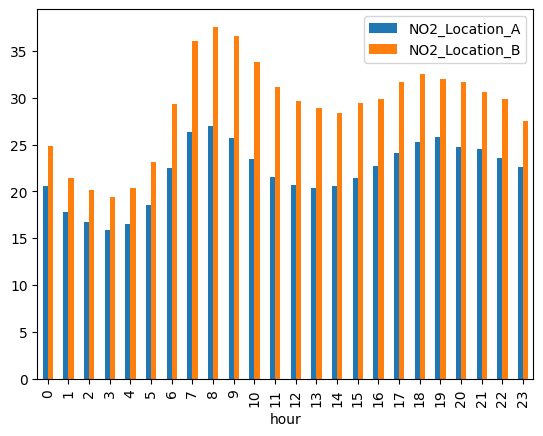

In [42]:
# Compare average NO2 per hour by location A and B
air_df.groupby(['hour'])[['NO2_Location_A','NO2_Location_B']].mean().plot.bar()
plt.show()

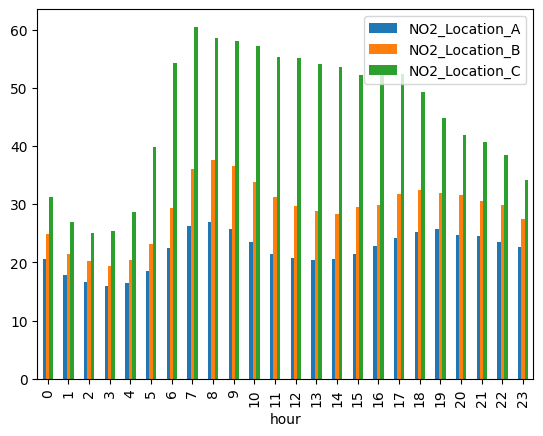

In [43]:
# Compare average NO2 per hour by location A, B, and C
air_df.groupby(['hour'])[['NO2_Location_A','NO2_Location_B','NO2_Location_C']].mean().plot.bar()
plt.show()

In [45]:
patient_df = pd.read_csv('kidney_disease.csv')

In [46]:
print('Number of missing values:')
for col in patient_df.columns:
    n_MV = sum(patient_df[col].isna())
    print('{}:{}'.format(col,n_MV))

Number of missing values:
rc:131
sc:17
pcv:71
sg:47
hemo:52
diagnosis:0


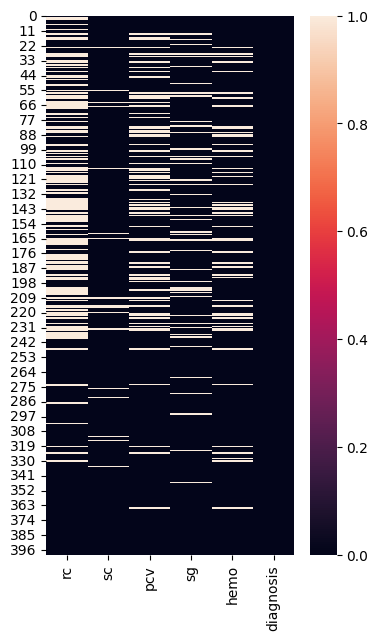

In [56]:
patient_df = pd.read_csv('kidney_disease.csv')
plt.figure(figsize=(4,7))
sns.heatmap(patient_df.isna())
plt.show()

Diagnosis Analysis for sc:


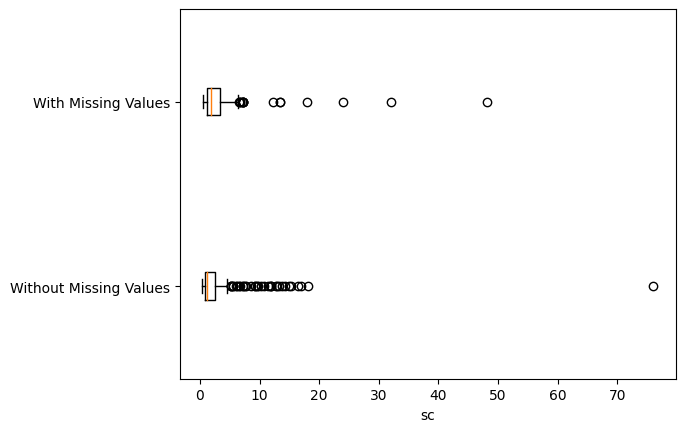

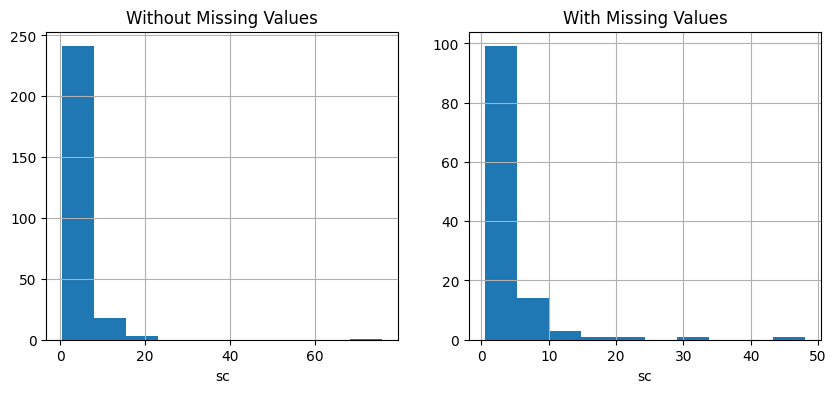

p-value of t-test: 0.18583257224831443
- - - - - - - - - divider - -  - - - - - - 
Diagnosis Analysis for pcv:


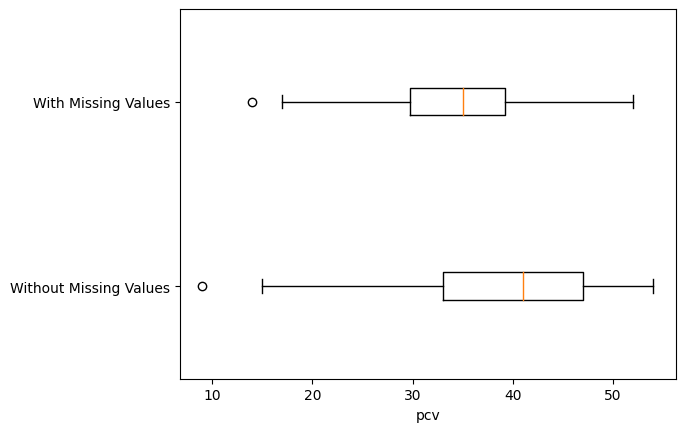

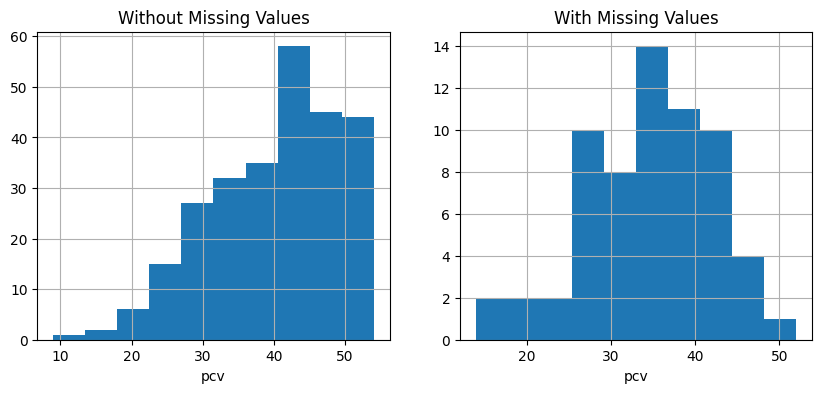

p-value of t-test: 1.552273251165168e-05
- - - - - - - - - divider - -  - - - - - - 
Diagnosis Analysis for sg:


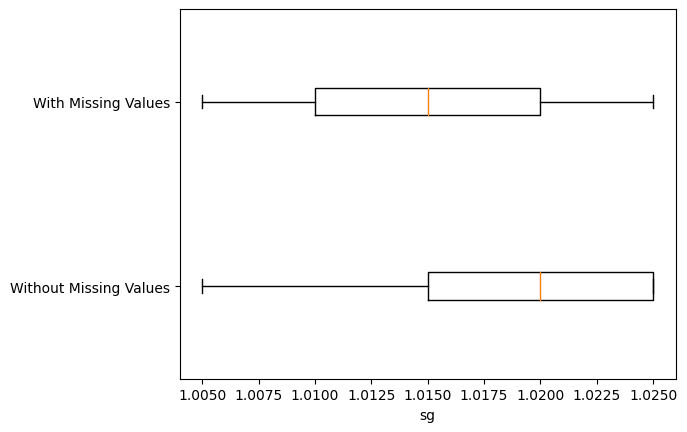

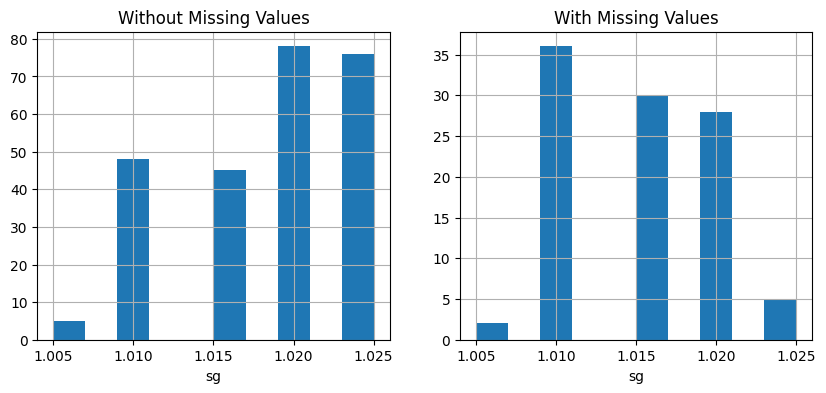

p-value of t-test: 1.0955628827436889e-07
- - - - - - - - - divider - -  - - - - - - 
Diagnosis Analysis for hemo:


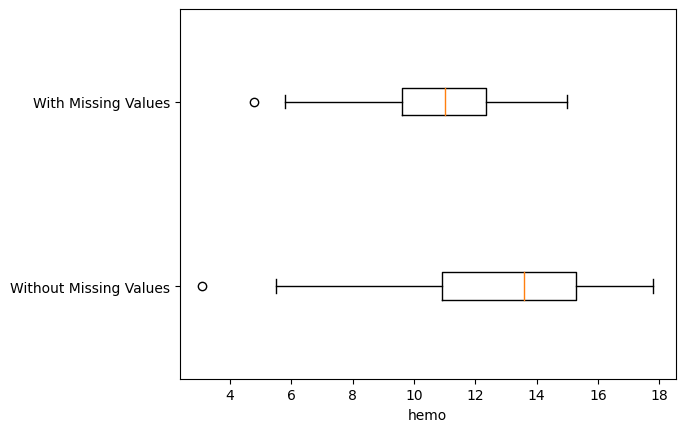

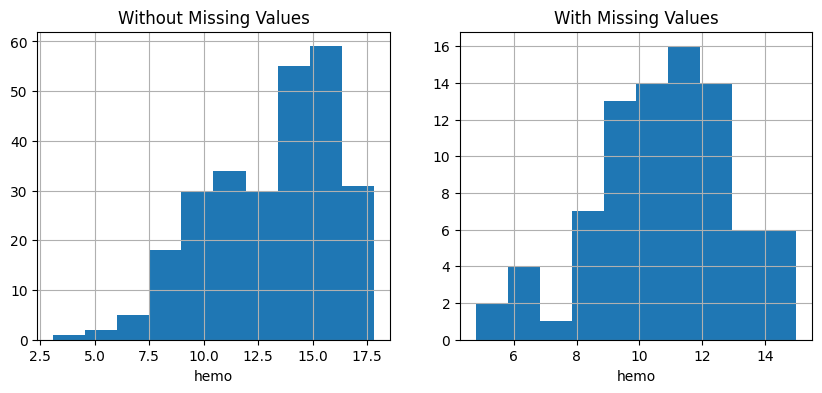

p-value of t-test: 2.9763626466020436e-10
- - - - - - - - - divider - -  - - - - - - 
Diagnosis Analysis for diagnosis:


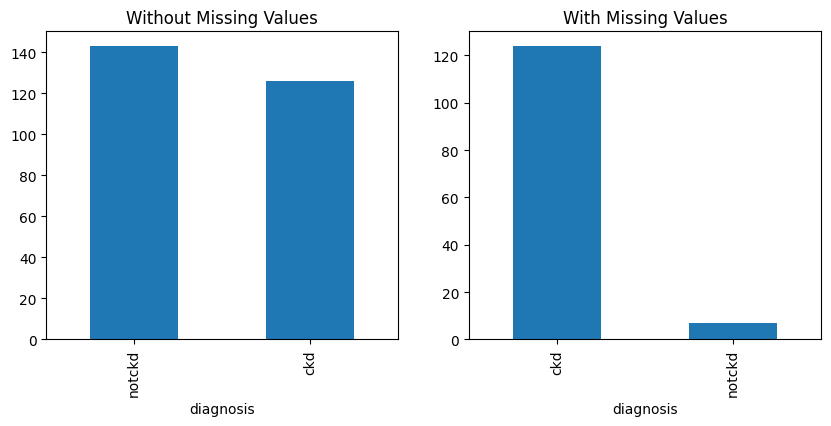

P-value of Chi_squared test: 5.168131718514657e-20
Diagnosis is influencing the tendency of missing values
- - - - - - - - - divider - - - - - - - - - 


In [57]:
# Examine relationship between missing values in rc vs other fields
categorical_attributes = ['diagnosis']
numerical_attributes = ['sc','pcv','sg','hemo']

BM_MV = patient_df.rc.isna()
for att in numerical_attributes:
    print('Diagnosis Analysis for {}:'.format(att))
    Diagnose_MV_Numerical(patient_df,att,BM_MV)
    print('- - - - - - - - - divider - -  - - - - - - ')
for att in categorical_attributes:
    print('Diagnosis Analysis for {}:'.format(att))
    Diagnose_MV_Categorical(patient_df,att,BM_MV)
    print('- - - - - - - - - divider - - - - - - - - - ')

Diagnosis Analysis for rc:


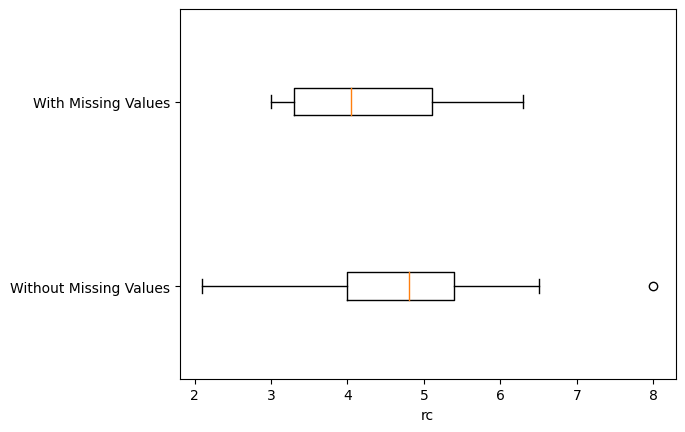

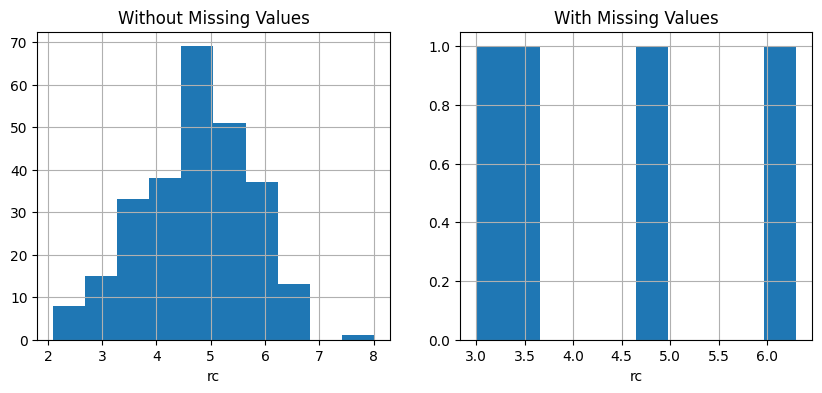

p-value of t-test: 0.4834207705489211
- - - - - - - - - divider - -  - - - - - - 
Diagnosis Analysis for sc:


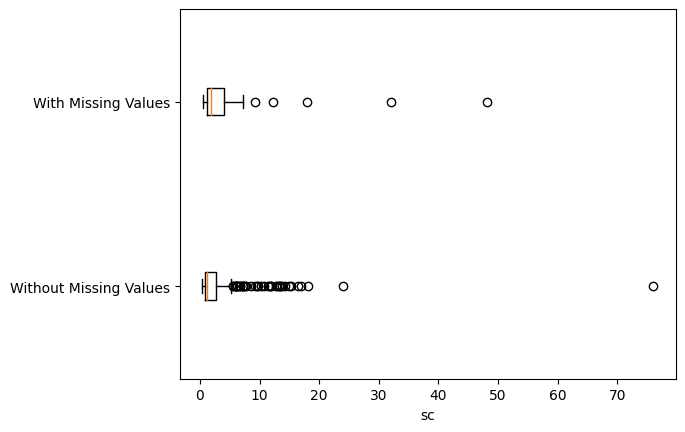

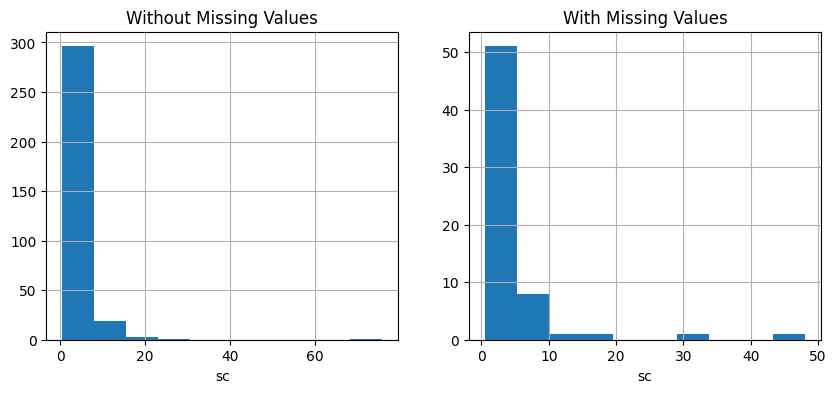

p-value of t-test: 0.09225178215961609
- - - - - - - - - divider - -  - - - - - - 
Diagnosis Analysis for sg:


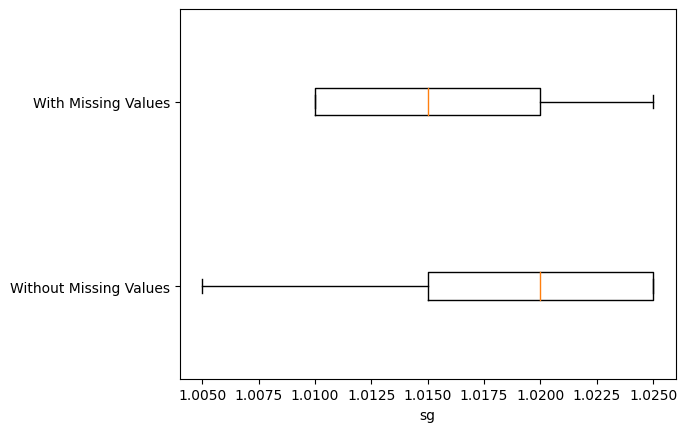

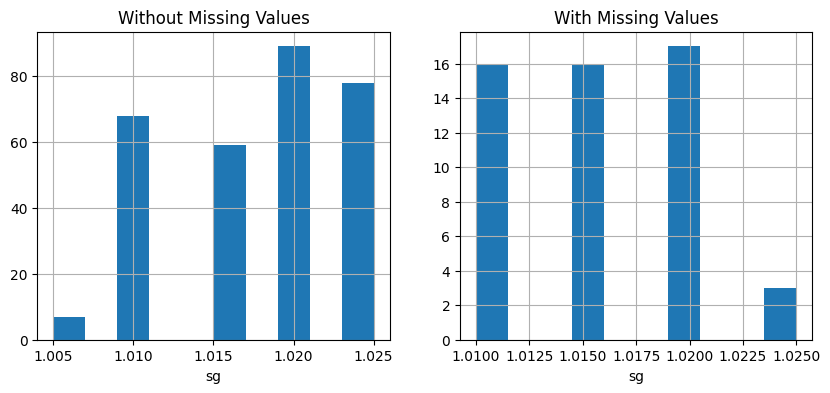

p-value of t-test: 0.01757923566523417
- - - - - - - - - divider - -  - - - - - - 
Diagnosis Analysis for hemo:


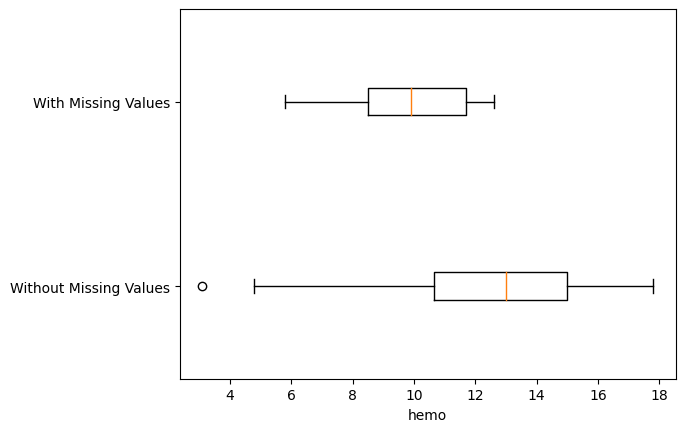

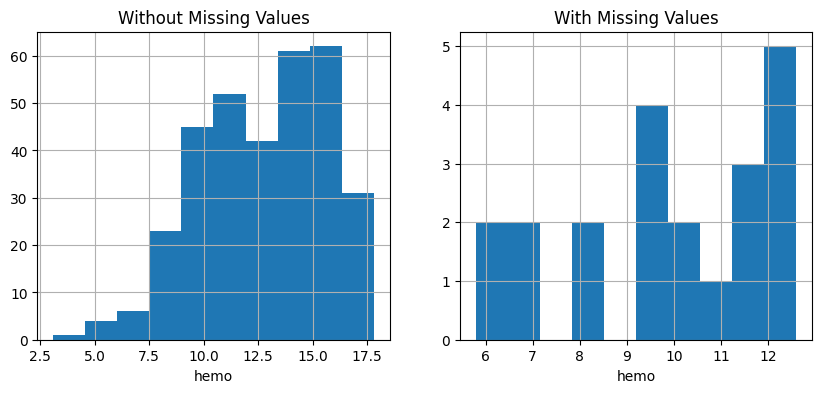

p-value of t-test: 1.5664018538667493e-05
- - - - - - - - - divider - -  - - - - - - 
Diagnosis Analysis for diagnosis:


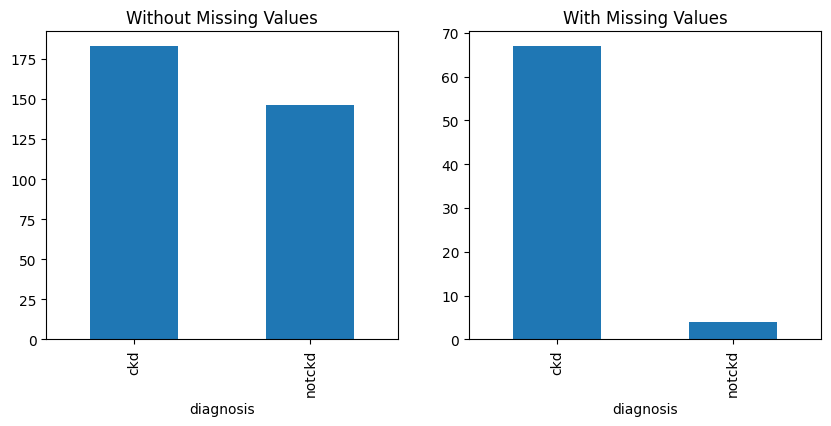

P-value of Chi_squared test: 2.2258514131489864e-09
Diagnosis is influencing the tendency of missing values
- - - - - - - - - divider - - - - - - - - - 


In [58]:
# Examine relationship between missing values in pcv vs other fields
categorical_attributes = ['diagnosis']
numerical_attributes = ['rc','sc','sg','hemo']

BM_MV = patient_df.pcv.isna()
for att in numerical_attributes:
    print('Diagnosis Analysis for {}:'.format(att))
    Diagnose_MV_Numerical(patient_df,att,BM_MV)
    print('- - - - - - - - - divider - -  - - - - - - ')
for att in categorical_attributes:
    print('Diagnosis Analysis for {}:'.format(att))
    Diagnose_MV_Categorical(patient_df,att,BM_MV)
    print('- - - - - - - - - divider - - - - - - - - - ')

Diagnosis Analysis for rc:


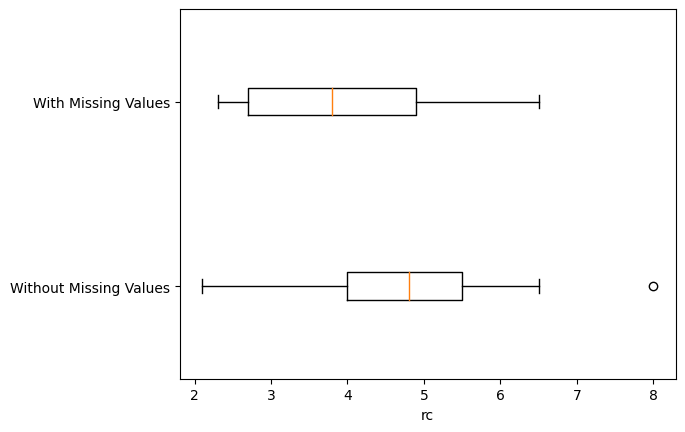

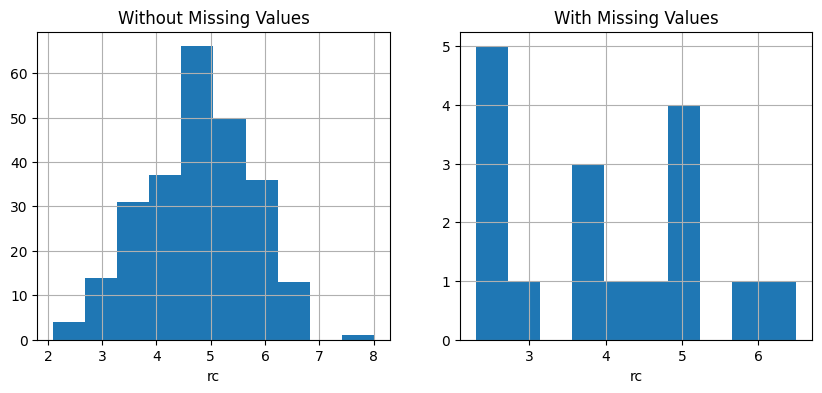

p-value of t-test: 0.00225068644343712
- - - - - - - - - divider - -  - - - - - - 
Diagnosis Analysis for sc:


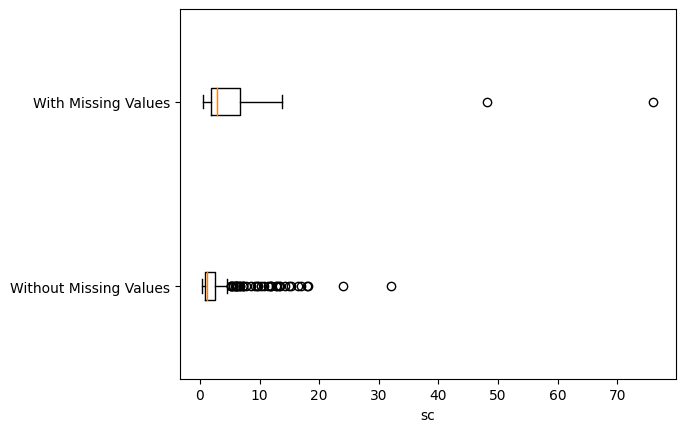

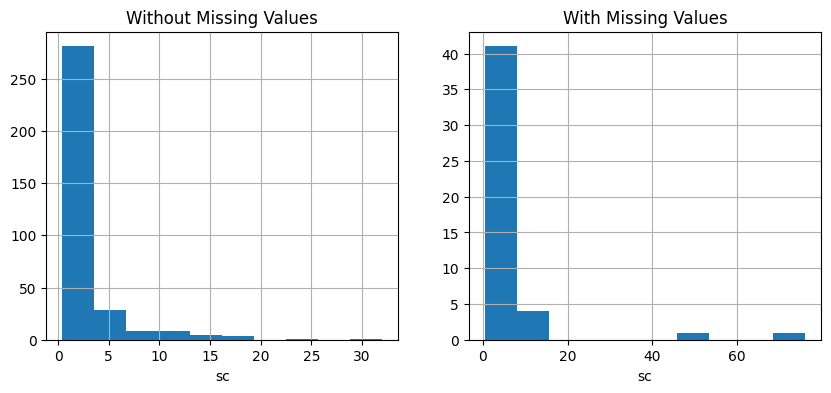

p-value of t-test: 7.153109526995942e-06
- - - - - - - - - divider - -  - - - - - - 
Diagnosis Analysis for pcv:


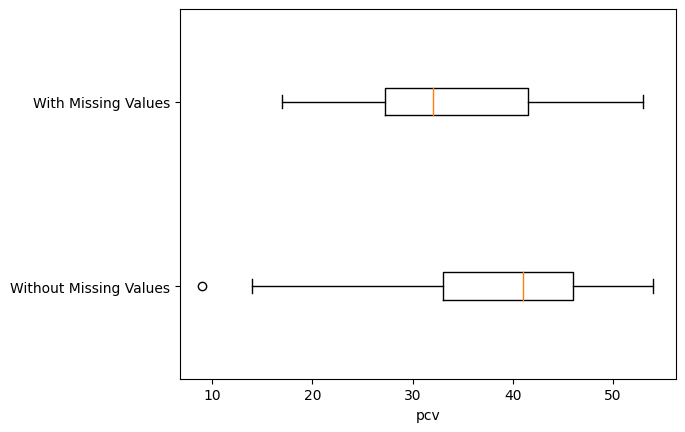

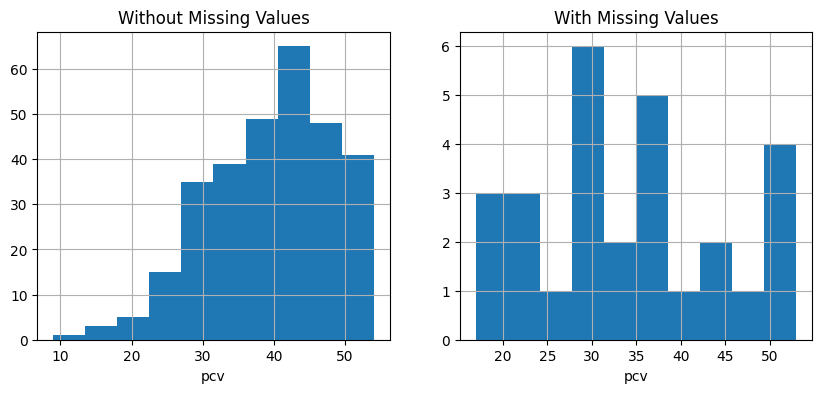

p-value of t-test: 0.0014894695918489607
- - - - - - - - - divider - -  - - - - - - 
Diagnosis Analysis for hemo:


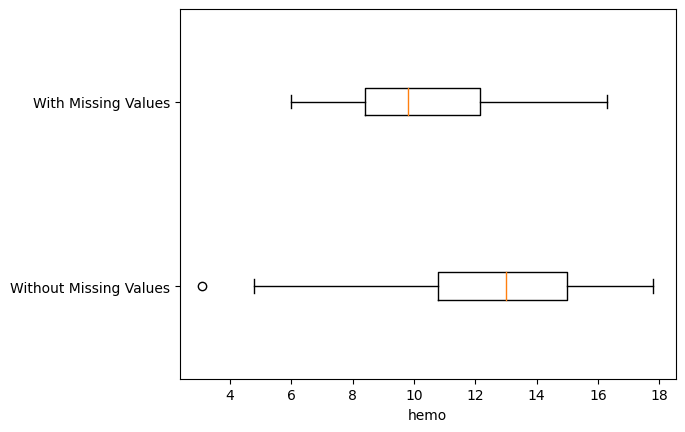

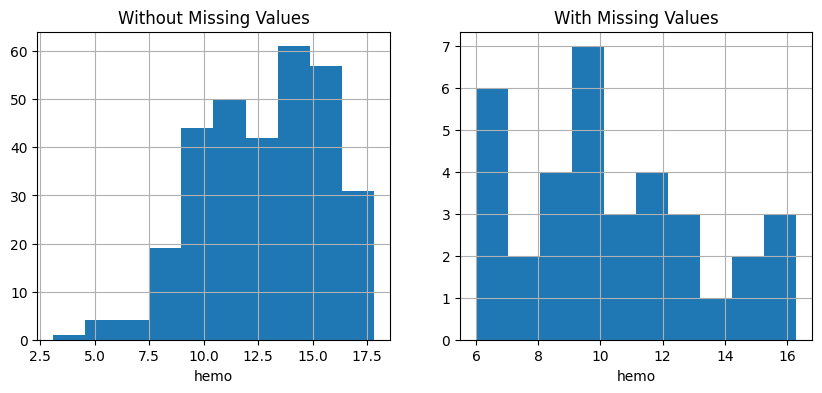

p-value of t-test: 2.7119421233597055e-06
- - - - - - - - - divider - -  - - - - - - 
Diagnosis Analysis for diagnosis:


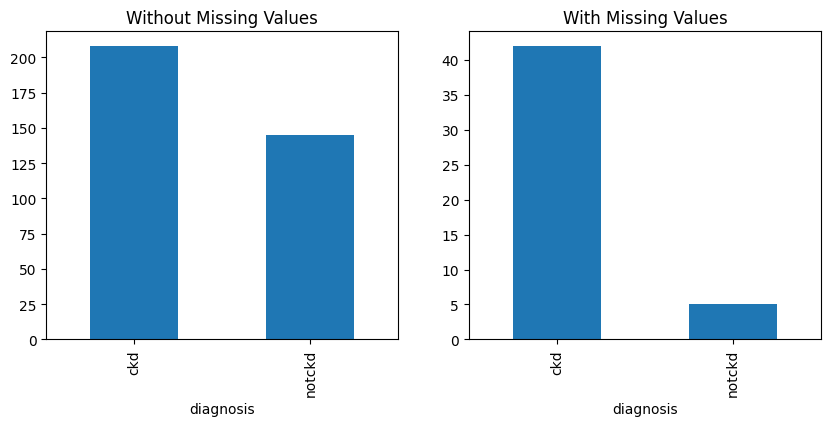

P-value of Chi_squared test: 0.00010072544367170718
Diagnosis is influencing the tendency of missing values
- - - - - - - - - divider - - - - - - - - - 


In [59]:
# Examine relationship between missing values in sg vs other fields
categorical_attributes = ['diagnosis']
numerical_attributes = ['rc','sc','pcv','hemo']

BM_MV = patient_df.sg.isna()
for att in numerical_attributes:
    print('Diagnosis Analysis for {}:'.format(att))
    Diagnose_MV_Numerical(patient_df,att,BM_MV)
    print('- - - - - - - - - divider - -  - - - - - - ')
for att in categorical_attributes:
    print('Diagnosis Analysis for {}:'.format(att))
    Diagnose_MV_Categorical(patient_df,att,BM_MV)
    print('- - - - - - - - - divider - - - - - - - - - ')

Diagnosis Analysis for rc:


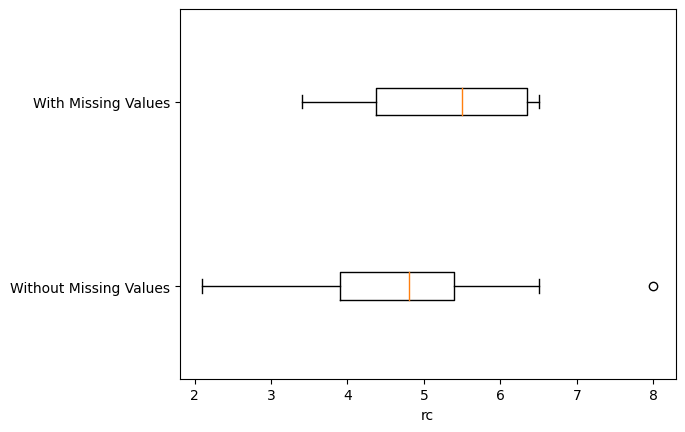

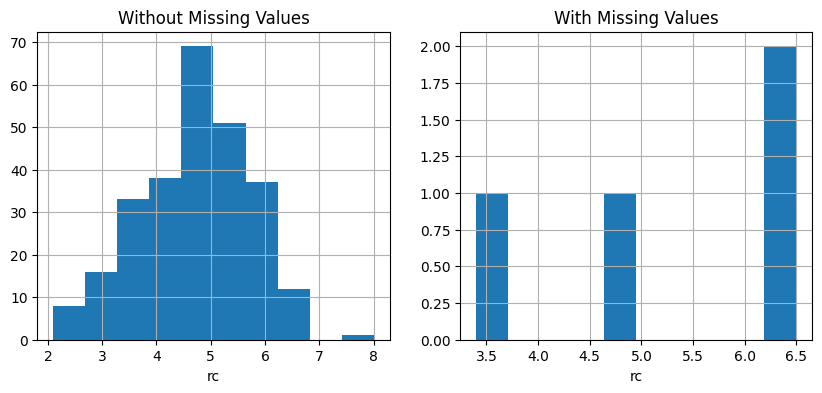

p-value of t-test: 0.30996898190520206
- - - - - - - - - divider - -  - - - - - - 
Diagnosis Analysis for sc:


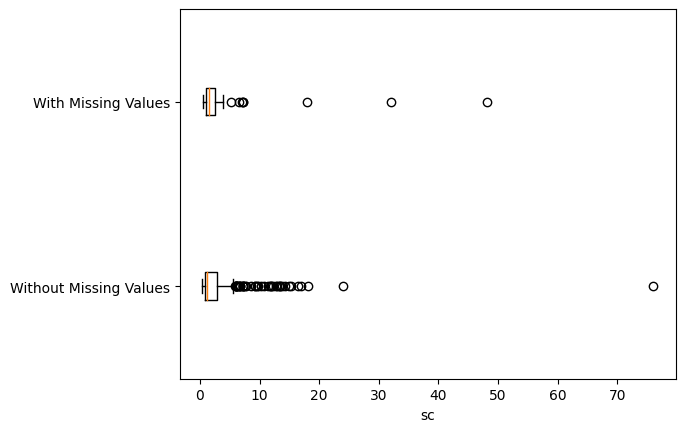

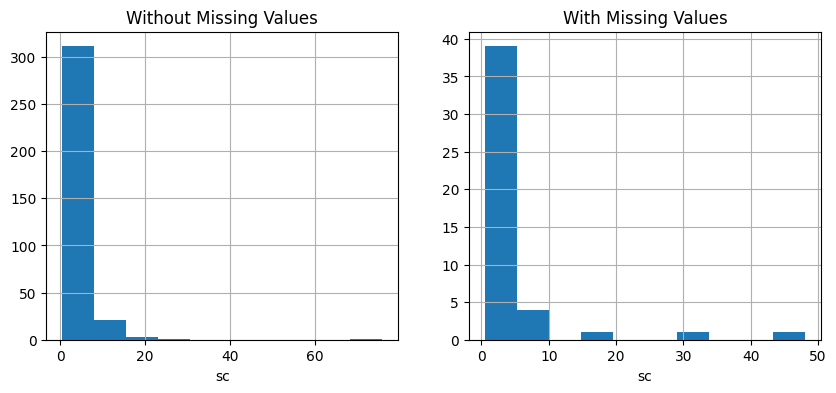

p-value of t-test: 0.17771862389361792
- - - - - - - - - divider - -  - - - - - - 
Diagnosis Analysis for pcv:


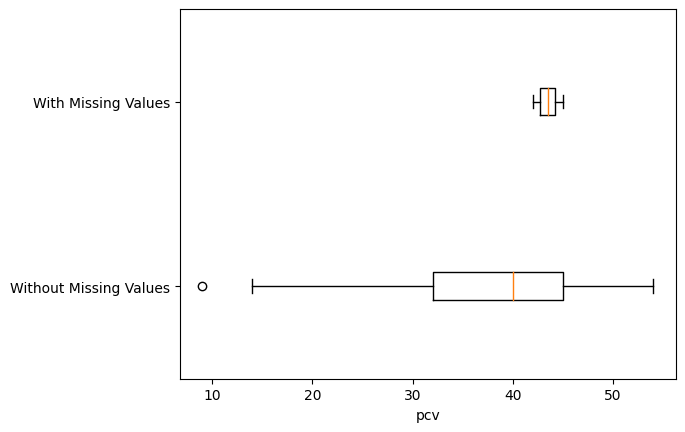

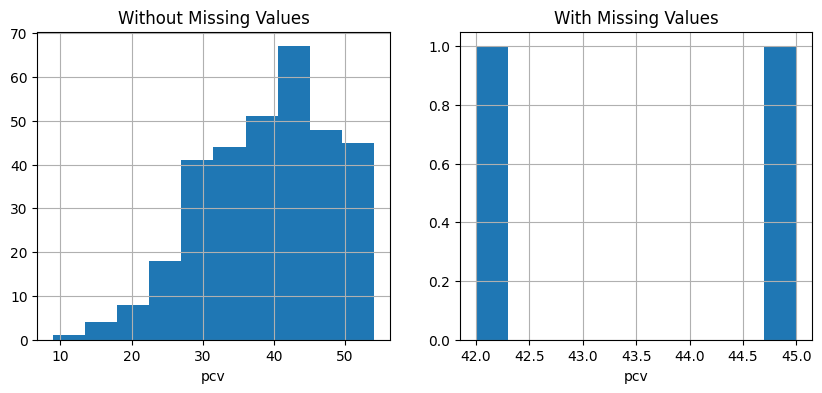

p-value of t-test: 0.46728803939148567
- - - - - - - - - divider - -  - - - - - - 
Diagnosis Analysis for sg:


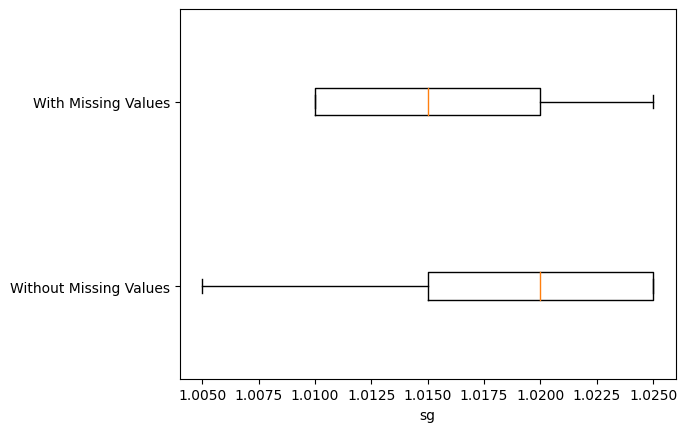

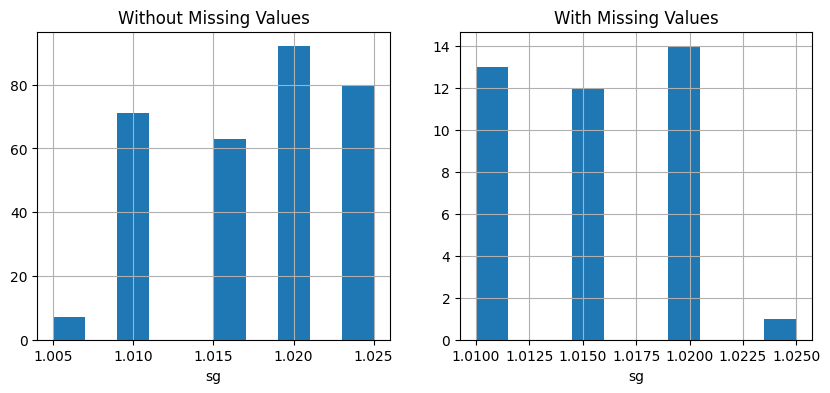

p-value of t-test: 0.016703395424493714
- - - - - - - - - divider - -  - - - - - - 
Diagnosis Analysis for diagnosis:


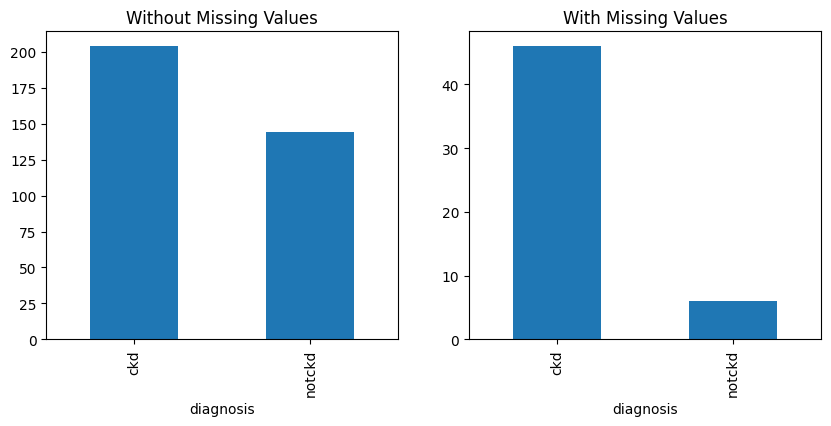

P-value of Chi_squared test: 6.542728784321527e-05
Diagnosis is influencing the tendency of missing values
- - - - - - - - - divider - - - - - - - - - 


In [60]:
# Examine relationship between missing values in sg vs other fields
categorical_attributes = ['diagnosis']
numerical_attributes = ['rc','sc','pcv','sg']

BM_MV = patient_df.hemo.isna()
for att in numerical_attributes:
    print('Diagnosis Analysis for {}:'.format(att))
    Diagnose_MV_Numerical(patient_df,att,BM_MV)
    print('- - - - - - - - - divider - -  - - - - - - ')
for att in categorical_attributes:
    print('Diagnosis Analysis for {}:'.format(att))
    Diagnose_MV_Categorical(patient_df,att,BM_MV)
    print('- - - - - - - - - divider - - - - - - - - - ')

In [61]:
# Add binary fields for each independent variable indicating missing or not missing field value
# BMV = binary multivariate value
patient_df['rc_BMV'] = patient_df.rc.isna().astype(int)
patient_df['pcv_BMV'] = patient_df.pcv.isna().astype(int)
patient_df['sg_BMV'] = patient_df.sg.isna().astype(int)
patient_df['hemo_BMV'] = patient_df.hemo.isna().astype(int)

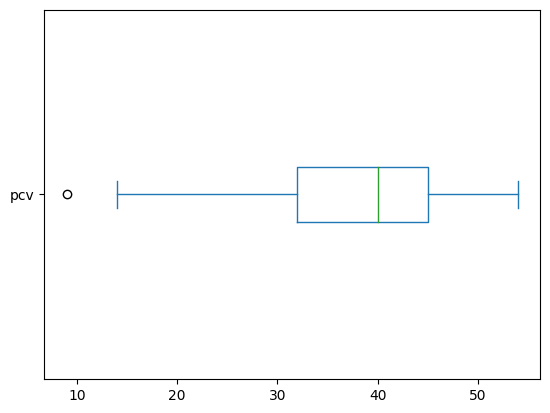

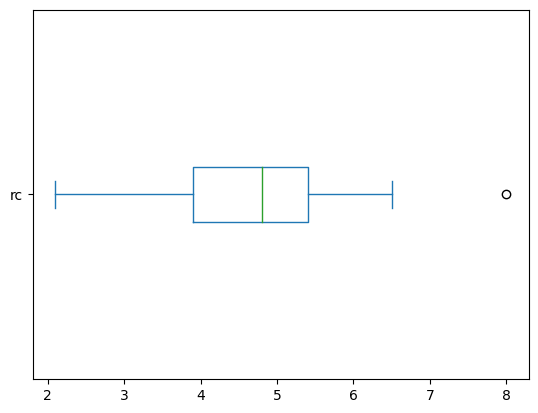

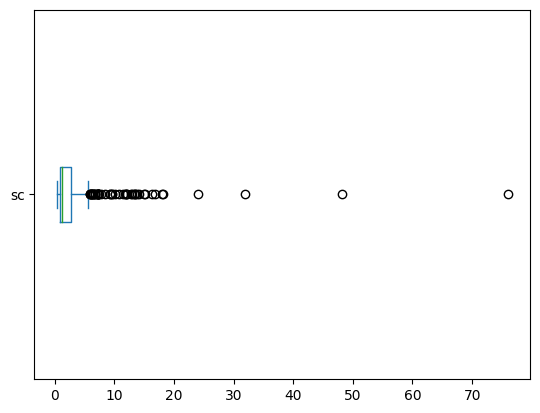

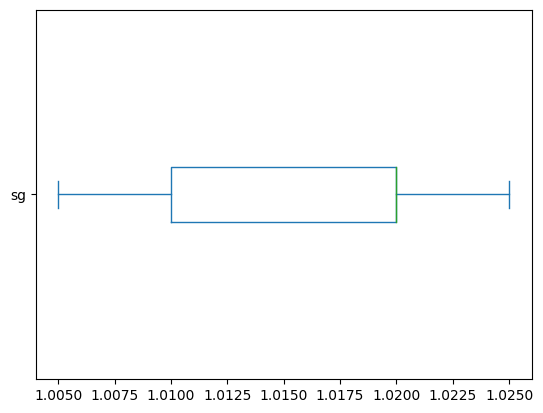

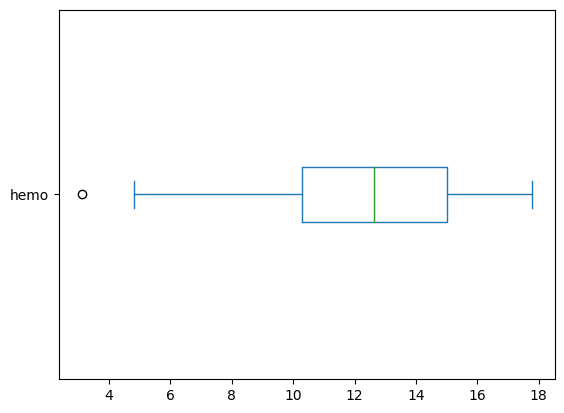

In [62]:
numerical_attributes = ['pcv','rc','sc','sg','hemo']
for att in numerical_attributes:
    patient_df[att].plot.box(vert=False)
    plt.show()

In [64]:
# Populate missing sc values with the median beause of high number of missing records value and it was skewed
patient_df.sc.fillna(patient_df.sc.median(),inplace=True)

In [80]:
# Populate other missing values with the general mean                     
patient_df.fillna(patient_df['rc'].mean(),inplace=True)
patient_df.fillna(patient_df['pcv'].mean(),inplace=True)
patient_df.fillna(patient_df['sg'].mean(),inplace=True)
patient_df.fillna(patient_df['hemo'].mean(),inplace=True)


In [82]:
patient_df.isna().sum()

rc           0
sc           0
pcv          0
sg           0
hemo         0
diagnosis    0
rc_BMV       0
pcv_BMV      0
sg_BMV       0
hemo_BMV     0
dtype: int64

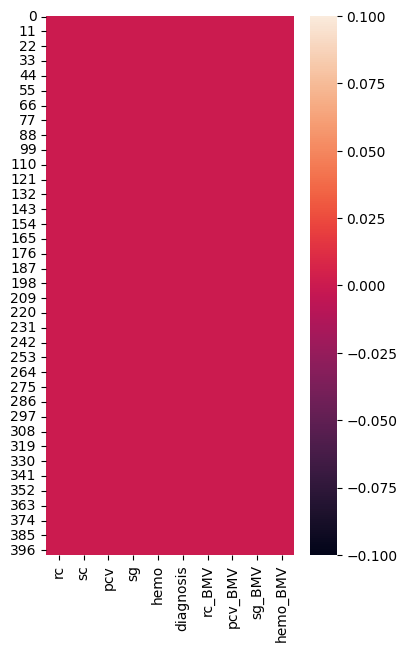

In [83]:
plt.figure(figsize=(4,7))
sns.heatmap(patient_df.isna())
plt.show()

### Decision Tree after missing values populated

In [84]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [92]:
predictors = ['rc','sc','pcv','sg','hemo','rc_BMV','pcv_BMV','sg_BMV','hemo_BMV']
target = 'diagnosis'
Xs = patient_df[predictors]
y = patient_df[target]

classTree = DecisionTreeClassifier(min_impurity_decrease=0.01,
                                   min_samples_split=15)
classTree.fit(Xs, y)

DecisionTreeClassifier(min_impurity_decrease=0.01, min_samples_split=15)

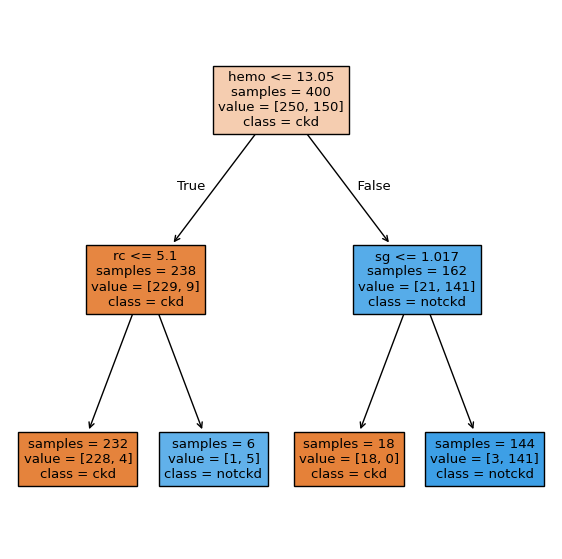

In [96]:
plt.figure(figsize=(7,7))
plot_tree(classTree,
          feature_names=predictors,
          class_names=y.unique(),
          filled=True,
          impurity=False)
plt.show()

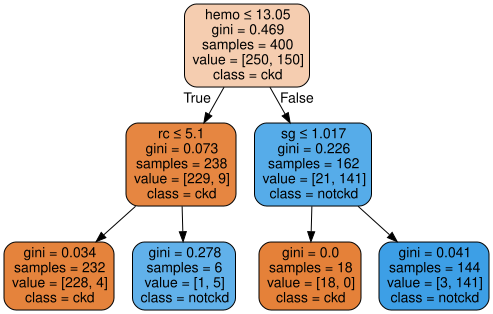

In [97]:
import graphviz
from sklearn.tree import export_graphviz
dot_data = export_graphviz(classTree, out_file=None, feature_names=Xs.columns,  
                           class_names=y.unique(), filled=True,
                           rounded=True, special_characters=True)  
graph = graphviz.Source(dot_data)  
graph 

## Outliers

### Detecting Outliers

#### Univariate Outlier Detection

In [98]:
column_df = pd.read_csv('columns.csv')
column_df.head(5)

,original,short
0,I enjoy listening to music.,Music
1,I prefer.,Slow songs or fast songs
2,"Dance, Disco, Funk",Dance
3,Folk music,Folk
4,Country,Country


In [99]:
response_df = pd.read_csv('responses.csv')
response_df.head(5)

,Music,Slow songs or fast songs,Dance,Folk,Country,Classical music,Musical,Pop,Rock,Metal or Hardrock,...,Age,Height,Weight,Number of siblings,Gender,Left - right handed,Education,Only child,Village - town,House - block of flats
0,5.0,3.0,2.0,1.0,2.0,2.0,1.0,5.0,5.0,1.0,...,20.0,163.0,48.0,1.0,female,right handed,college/bachelor degree,no,village,block of flats
1,4.0,4.0,2.0,1.0,1.0,1.0,2.0,3.0,5.0,4.0,...,19.0,163.0,58.0,2.0,female,right handed,college/bachelor degree,no,city,block of flats
2,5.0,5.0,2.0,2.0,3.0,4.0,5.0,3.0,5.0,3.0,...,20.0,176.0,67.0,2.0,female,right handed,secondary school,no,city,block of flats
3,5.0,3.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,...,22.0,172.0,59.0,1.0,female,right handed,college/bachelor degree,yes,city,house/bungalow
4,5.0,3.0,4.0,3.0,2.0,4.0,3.0,5.0,3.0,1.0,...,20.0,170.0,59.0,1.0,female,right handed,secondary school,no,village,house/bungalow


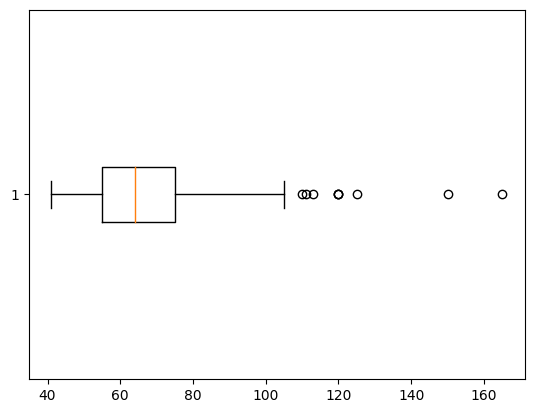

In [100]:
fig = plt.boxplot(response_df['Weight'].dropna(),vert=False)

In [101]:
response_df[response_df['Weight']>105]

,Music,Slow songs or fast songs,Dance,Folk,Country,Classical music,Musical,Pop,Rock,Metal or Hardrock,...,Age,Height,Weight,Number of siblings,Gender,Left - right handed,Education,Only child,Village - town,House - block of flats
292,5.0,4.0,5.0,2.0,3.0,2.0,5.0,5.0,4.0,1.0,...,21.0,184.0,120.0,1.0,female,right handed,secondary school,no,city,house/bungalow
612,5.0,3.0,5.0,1.0,1.0,3.0,2.0,3.0,4.0,3.0,...,23.0,172.0,110.0,2.0,male,right handed,secondary school,no,village,block of flats
715,4.0,3.0,2.0,3.0,3.0,3.0,4.0,2.0,5.0,5.0,...,29.0,183.0,111.0,1.0,male,left handed,secondary school,no,village,house/bungalow
793,2.0,3.0,3.0,1.0,2.0,3.0,3.0,3.0,2.0,4.0,...,24.0,185.0,120.0,2.0,male,right handed,doctorate degree,no,city,house/bungalow
796,3.0,5.0,3.0,2.0,2.0,4.0,3.0,5.0,1.0,4.0,...,27.0,189.0,113.0,3.0,male,left handed,doctorate degree,no,city,house/bungalow
859,5.0,3.0,4.0,4.0,2.0,3.0,3.0,4.0,3.0,2.0,...,20.0,190.0,125.0,1.0,male,right handed,secondary school,no,city,block of flats
885,3.0,4.0,3.0,2.0,2.0,2.0,3.0,4.0,4.0,4.0,...,23.0,NaN,165.0,0.0,female,right handed,secondary school,yes,city,house/bungalow
973,5.0,3.0,2.0,5.0,5.0,4.0,5.0,2.0,5.0,5.0,...,20.0,175.0,120.0,2.0,female,right handed,secondary school,no,city,block of flats
992,4.0,4.0,4.0,1.0,4.0,4.0,1.0,3.0,4.0,4.0,...,30.0,200.0,150.0,1.0,male,right handed,masters degree,no,city,block of flats


In [102]:
print(fig)

{'whiskers': [<matplotlib.lines.Line2D object at 0x000001D971F4A5D0>, <matplotlib.lines.Line2D object at 0x000001D979758650>], 'caps': [<matplotlib.lines.Line2D object at 0x000001D97975B410>, <matplotlib.lines.Line2D object at 0x000001D9797591D0>], 'boxes': [<matplotlib.lines.Line2D object at 0x000001D97975B7D0>], 'medians': [<matplotlib.lines.Line2D object at 0x000001D979759B10>], 'fliers': [<matplotlib.lines.Line2D object at 0x000001D9792A9090>], 'means': []}


In [120]:
# retrieve the upper outlier data points
fig['fliers'][0].get_data()[0]

array([120., 110., 111., 120., 113., 125., 165., 120., 150.])

In [121]:
# retrieve the upper outlier data points
# returns an error if there are no outliers
fig['fliers'][2].get_data()[0]

IndexError: list index out of range

In [123]:
# retrieve the lower whisker outlier value
fig['caps'][0].get_data()[0][0]

41.0

In [124]:
# retrieve the upper whisker outlier value
fig['caps'][1].get_data()[0][0]

105.0

In [125]:
# Retrieve outliers using IQR methodology
Q1 = response_df['Weight'].quantile(0.25)
Q3 = response_df['Weight'].quantile(0.75)
IQR = Q3-Q1

BM = (response_df.Weight > (Q3+1.5*IQR)) | (response_df.Weight < (Q1-1.5*IQR))
response_df[BM]

,Music,Slow songs or fast songs,Dance,Folk,Country,Classical music,Musical,Pop,Rock,Metal or Hardrock,...,Age,Height,Weight,Number of siblings,Gender,Left - right handed,Education,Only child,Village - town,House - block of flats
292,5.0,4.0,5.0,2.0,3.0,2.0,5.0,5.0,4.0,1.0,...,21.0,184.0,120.0,1.0,female,right handed,secondary school,no,city,house/bungalow
612,5.0,3.0,5.0,1.0,1.0,3.0,2.0,3.0,4.0,3.0,...,23.0,172.0,110.0,2.0,male,right handed,secondary school,no,village,block of flats
715,4.0,3.0,2.0,3.0,3.0,3.0,4.0,2.0,5.0,5.0,...,29.0,183.0,111.0,1.0,male,left handed,secondary school,no,village,house/bungalow
793,2.0,3.0,3.0,1.0,2.0,3.0,3.0,3.0,2.0,4.0,...,24.0,185.0,120.0,2.0,male,right handed,doctorate degree,no,city,house/bungalow
796,3.0,5.0,3.0,2.0,2.0,4.0,3.0,5.0,1.0,4.0,...,27.0,189.0,113.0,3.0,male,left handed,doctorate degree,no,city,house/bungalow
859,5.0,3.0,4.0,4.0,2.0,3.0,3.0,4.0,3.0,2.0,...,20.0,190.0,125.0,1.0,male,right handed,secondary school,no,city,block of flats
885,3.0,4.0,3.0,2.0,2.0,2.0,3.0,4.0,4.0,4.0,...,23.0,NaN,165.0,0.0,female,right handed,secondary school,yes,city,house/bungalow
973,5.0,3.0,2.0,5.0,5.0,4.0,5.0,2.0,5.0,5.0,...,20.0,175.0,120.0,2.0,female,right handed,secondary school,no,city,block of flats
992,4.0,4.0,4.0,1.0,4.0,4.0,1.0,3.0,4.0,4.0,...,30.0,200.0,150.0,1.0,male,right handed,masters degree,no,city,block of flats


#### Detecting outlier for a categorical attribute

In [127]:
# The doctorate degree can be considered an outlier
response_df['Education'].value_counts()

Education
secondary school                    621
college/bachelor degree             212
masters degree                       81
primary school                       80
currently a primary school pupil     10
doctorate degree                      5
Name: count, dtype: int64

<Axes: xlabel='Education'>

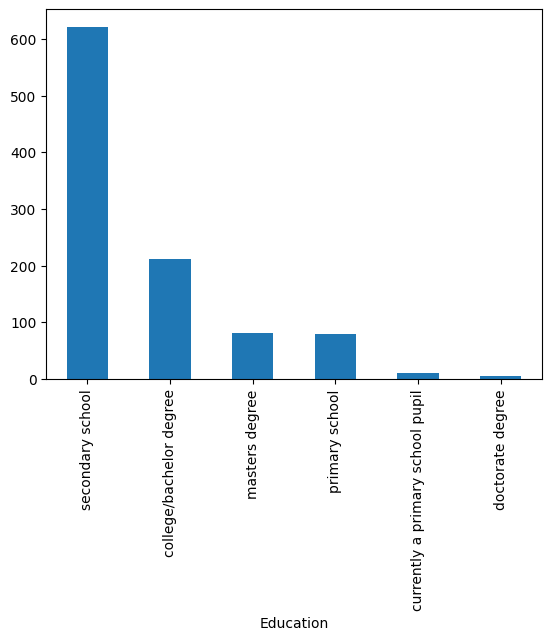

In [128]:
response_df['Education'].value_counts().plot.bar()

#### Bivariate Outlier Detection

#### Outlier detection across 2 numerical attributes

<Axes: xlabel='Height', ylabel='Weight'>

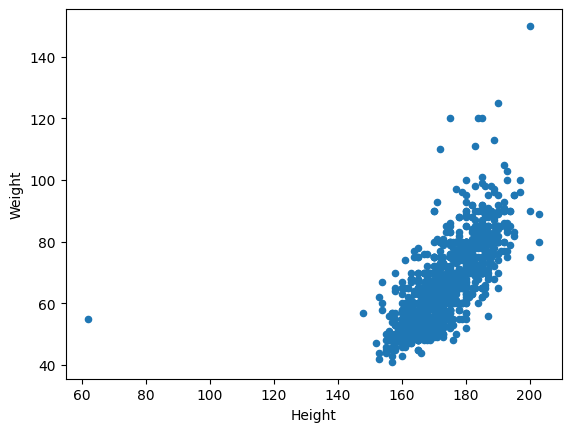

In [129]:
response_df.plot.scatter(x='Height',y='Weight')

In [130]:
# Filter the outlier rows with a boolean mask (BM)
BM = (response_df['Weight']>130) | (response_df['Height']<70)
response_df[BM]

,Music,Slow songs or fast songs,Dance,Folk,Country,Classical music,Musical,Pop,Rock,Metal or Hardrock,...,Age,Height,Weight,Number of siblings,Gender,Left - right handed,Education,Only child,Village - town,House - block of flats
676,5.0,4.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,...,20.0,62.0,55.0,2.0,female,right handed,college/bachelor degree,no,city,house/bungalow
885,3.0,4.0,3.0,2.0,2.0,2.0,3.0,4.0,4.0,4.0,...,23.0,NaN,165.0,0.0,female,right handed,secondary school,yes,city,house/bungalow
992,4.0,4.0,4.0,1.0,4.0,4.0,1.0,3.0,4.0,4.0,...,30.0,200.0,150.0,1.0,male,right handed,masters degree,no,city,block of flats


#### Outlier detection across 2 categorical attributes

In [131]:
pd.crosstab(response_df['Education'],response_df['God'])

God,1.0,2.0,3.0,4.0,5.0
Education,,,,,
college/bachelor degree,48,17,46,42,58
currently a primary school pupil,0,1,2,1,6
doctorate degree,1,1,1,0,2
masters degree,8,3,20,15,35
primary school,12,11,21,15,21
secondary school,118,89,126,92,195


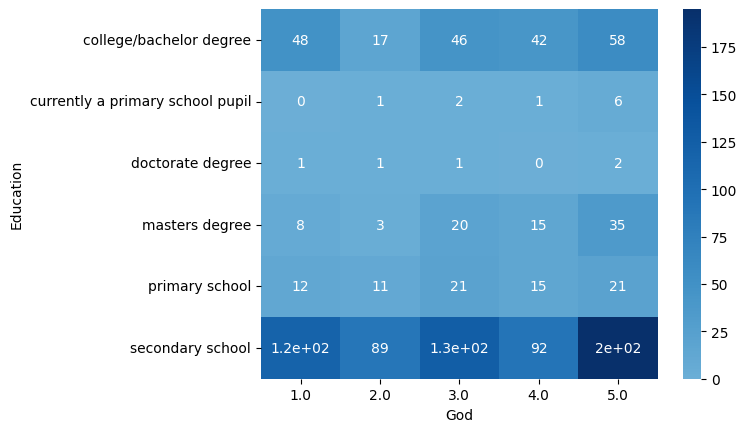

In [136]:
# create heatmap of contingency table to look for outliers between 2 categories
contingency_table = pd.crosstab(response_df['Education'],response_df['God'])
sns.heatmap(contingency_table, annot=True, center=0.5, cmap="Blues")
plt.show()

In [142]:
response_df.query('Education == "currently a primary school pupil" & God in(2,4)')

,Music,Slow songs or fast songs,Dance,Folk,Country,Classical music,Musical,Pop,Rock,Metal or Hardrock,...,Age,Height,Weight,Number of siblings,Gender,Left - right handed,Education,Only child,Village - town,House - block of flats
158,5.0,3.0,4.0,2.0,1.0,3.0,2.0,5.0,4.0,1.0,...,15.0,160.0,48.0,2.0,female,right handed,currently a primary school pupil,no,village,block of flats
950,5.0,3.0,2.0,3.0,NaN,4.0,2.0,4.0,5.0,5.0,...,15.0,190.0,85.0,0.0,male,left handed,currently a primary school pupil,yes,village,house/bungalow


In [144]:
response_df.query('Education=="doctorate degree" & God in(1,2,3)')

,Music,Slow songs or fast songs,Dance,Folk,Country,Classical music,Musical,Pop,Rock,Metal or Hardrock,...,Age,Height,Weight,Number of siblings,Gender,Left - right handed,Education,Only child,Village - town,House - block of flats
668,5.0,3.0,1.0,2.0,3.0,4.0,2.0,2.0,5.0,5.0,...,27.0,186.0,82.0,1.0,male,left handed,doctorate degree,yes,city,house/bungalow
793,2.0,3.0,3.0,1.0,2.0,3.0,3.0,3.0,2.0,4.0,...,24.0,185.0,120.0,2.0,male,right handed,doctorate degree,no,city,house/bungalow
796,3.0,5.0,3.0,2.0,2.0,4.0,3.0,5.0,1.0,4.0,...,27.0,189.0,113.0,3.0,male,left handed,doctorate degree,no,city,house/bungalow


#### Outlier detection for one categorical and one numerical

C:\Users\timry\AppData\Roaming\Python\Python311\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


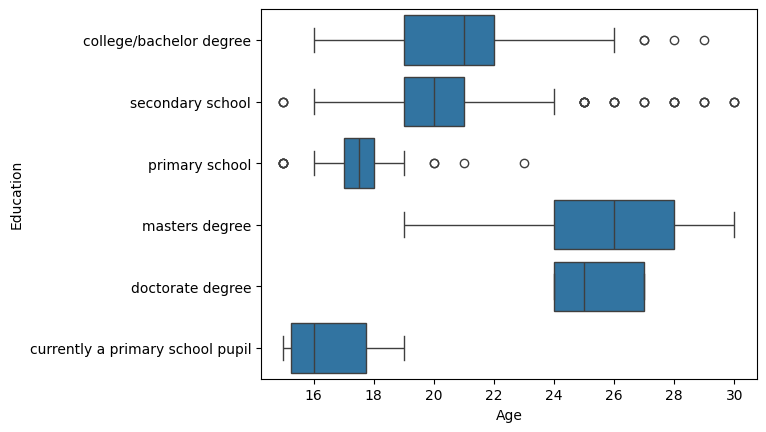

In [147]:
fig = sns.boxplot(x=response_df['Age'], y=response_df['Education'])
plt.show()

In [154]:
BM1 = (response_df["Education"]=="college/bachelor degree") & \
      (response_df['Age']>26)
BM2 = (response_df.Education == 'secondary school') & \
      ((response_df.Age>24) | (response_df.Age<16))
BM3 = (response_df.Education == 'primary school') & \
      ((response_df.Age>19) | (response_df.Age<16))
BM = BM1 | BM2 | BM3
response_df[BM].shape

(39, 150)

#### Multivariate Outlier Detection

In [164]:
dimensions = ['Country','Metal or Hardrock','Folk','Musical']
Xs = response_df[dimensions]

In [165]:
Xs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            1005 non-null   float64
 1   Metal or Hardrock  1007 non-null   float64
 2   Folk               1005 non-null   float64
 3   Musical            1008 non-null   float64
dtypes: float64(4)
memory usage: 31.7 KB


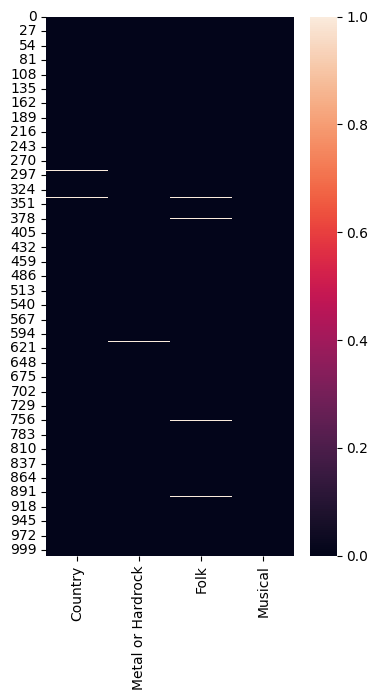

In [166]:
plt.figure(figsize=(4,7))
sns.heatmap(Xs.isna())
plt.show()

In [167]:
Q3 = Xs.quantile(0.75)
Q1 = Xs.quantile(0.25)
IQR = Q3-Q1
Xs = Xs.fillna(Q3+IQR*1.5)

In [168]:
Xs = (Xs-Xs.min())/(Xs.max()-Xs.min())

In [170]:
from sklearn.cluster import KMeans
for k in range(2,8):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(Xs)
    print('k={}'.format(k))
    for i in range(k):
        BM = kmeans.labels_==i
        print('Cluster {}: {}'.format(i,Xs[BM].index.values))
    print('--------- Divider ----------')

k=2
Cluster 0: [   1    2    5    8   12   15   18   19   20   21   24   26   32   34
   37   39   41   42   46   49   51   52   54   55   59   62   65   66
   68   75   82   83   84   85   86   89   91   93   96  100  101  104
  105  107  108  109  120  123  124  125  127  128  130  135  141  146
  147  150  151  154  157  159  160  161  166  167  169  172  175  176
  177  178  180  181  182  189  190  193  196  198  200  201  203  204
  205  206  209  210  214  216  221  222  224  226  227  231  233  234
  235  236  245  248  249  255  257  258  260  264  267  269  270  271
  272  275  276  277  280  281  291  293  295  300  301  303  307  312
  314  320  322  325  328  330  339  345  347  350  352  356  357  361
  362  363  364  365  367  369  370  371  377  381  383  384  385  386
  393  395  398  399  401  402  412  413  417  420  423  425  426  429
  432  433  435  438  444  452  454  471  473  475  476  477  479  481
  483  484  487  488  502  505  506  510  513  515  516  517  

## Dealing with Outliers

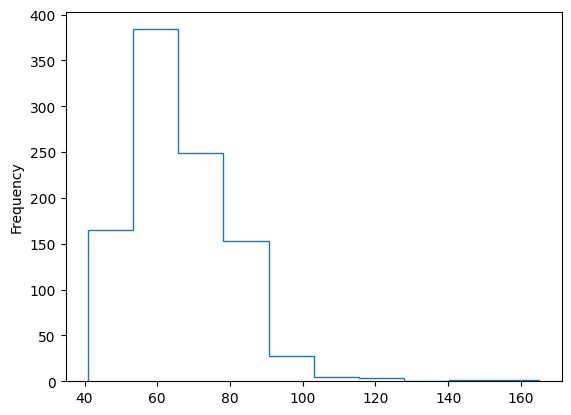

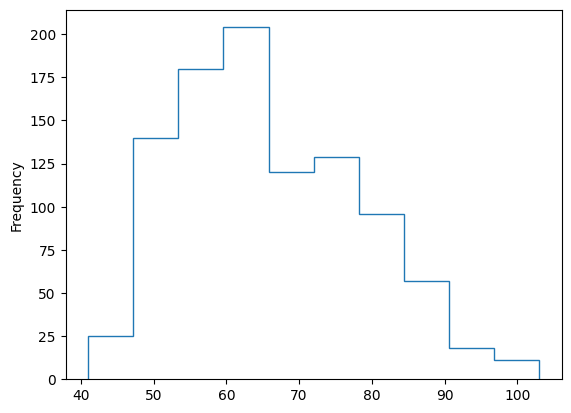

In [173]:
# Example 1
response_df['Weight'].plot.hist(histtype='step')
plt.show()
BM = response_df['Weight']<105
response_df['Weight'][BM].plot.hist(histtype='step')
plt.show()

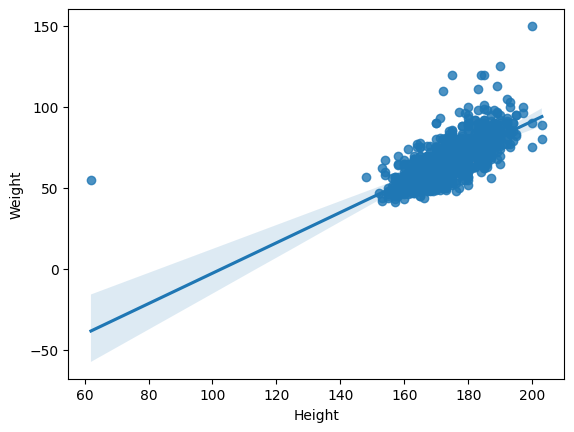

In [175]:
# Example 2
# linear regression plot with outliers
sns.regplot(x='Height',
            y='Weight',
            data = response_df)
plt.show()

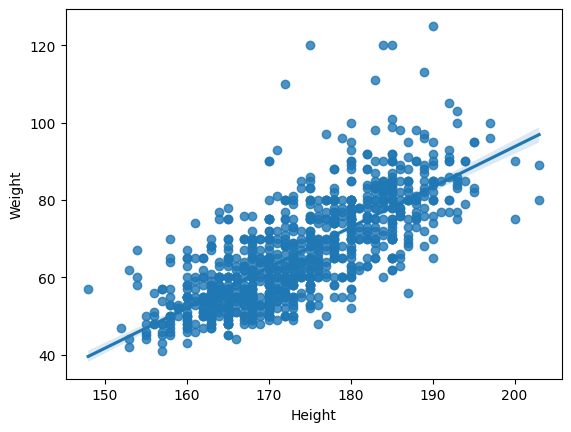

In [176]:
# linear regression without the outliers
BM = (response_df['Weight']>130) | (response_df['Height']<70)
sns.regplot(x='Height',
            y='Weight',
            data=response_df[~BM])
plt.show()

### Example 3 - Linear Regression With Cleanup

#### Ex3: Dealing with Missing Values

In [198]:
select_attributes = ['Weight','Height','Gender']
pre_process_df = pd.DataFrame(response_df[select_attributes])
pre_process_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  990 non-null    float64
 1   Height  990 non-null    float64
 2   Gender  1004 non-null   object 
dtypes: float64(2), object(1)
memory usage: 23.8+ KB


In [199]:
# Drop the null values
# Assumptions were MCAR type and linear regression to be used
pre_process_df.dropna(inplace=True)

In [200]:
pre_process_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 975 entries, 0 to 1009
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  975 non-null    float64
 1   Height  975 non-null    float64
 2   Gender  975 non-null    object 
dtypes: float64(2), object(1)
memory usage: 30.5+ KB


#### Ex3: Detecting univariate outliers and dealing with them

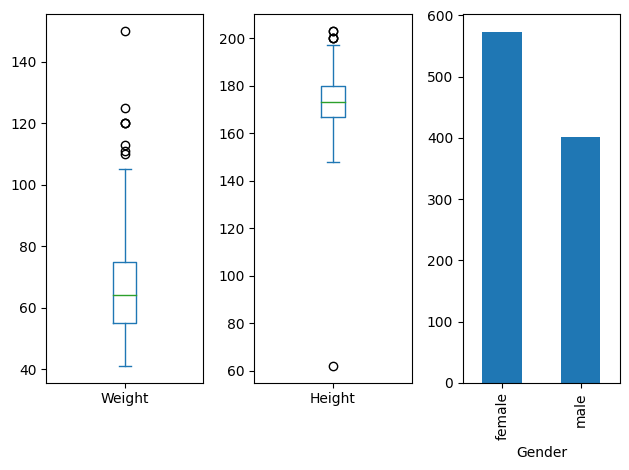

In [201]:
# plot boxplots for numeric attributes
num_attributes = ['Weight','Height']
for i, att in enumerate(num_attributes):
    plt.subplot(1,3,i+1)
    pre_process_df[att].plot.box()

# plot bar plot for categorical attribute    
plt.subplot(1,3,3)
pre_process_df['Gender'].value_counts().plot.bar()
plt.tight_layout()
plt.show()

In [202]:
# Change the outliers to the upper cap value for Weight
Q3 = pre_process_df['Weight'].quantile(0.75)
Q1 = pre_process_df['Weight'].quantile(0.25)
IQR = Q3-Q1

upper_cap = Q3+IQR*1.5

BM = pre_process_df['Weight'] > upper_cap
pre_process_df.loc[pre_process_df[BM].index,'Weight'] = upper_cap

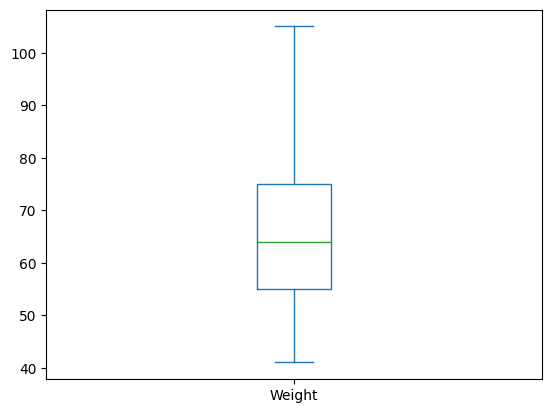

In [203]:
pre_process_df['Weight'].plot.box()
plt.show()

In [204]:
# Change the outliers to the upper/lower cap value for Height
Q3 = pre_process_df['Height'].quantile(0.75)
Q1 = pre_process_df['Height'].quantile(0.25)
IQR = Q3-Q1

lower_cap = Q1-IQR*1.5
upper_cap = Q3+IQR*1.5

BM = pre_process_df['Height']<lower_cap
pre_process_df.loc[pre_process_df[BM].index,'Height']=lower_cap

BM = pre_process_df['Height']>upper_cap
pre_process_df.loc[pre_process_df[BM].index,'Height']=upper_cap

<Axes: >

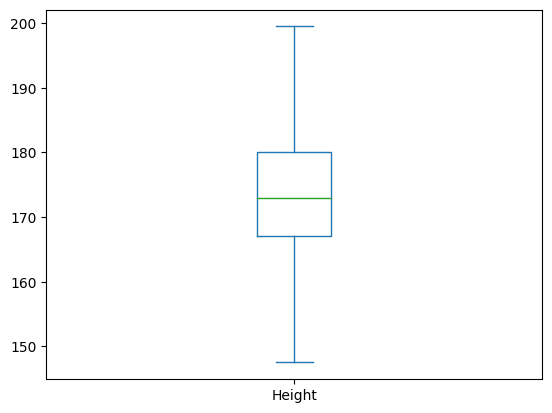

In [205]:
pre_process_df['Height'].plot.box()

#### Ex3: Detecting bivariate outliers and dealing with them

<Axes: xlabel='Height', ylabel='Weight'>

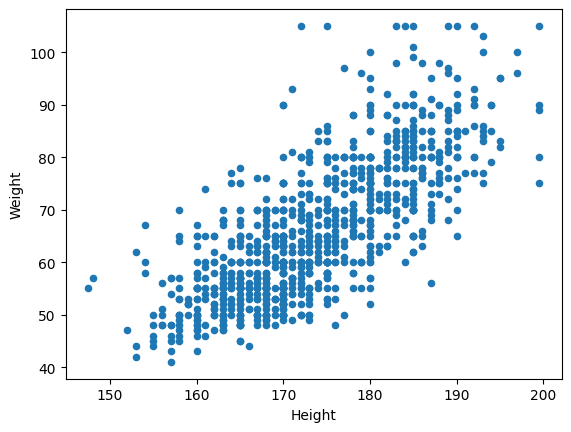

In [206]:
# look for outliers in the height/weight combination
# there were no outliers shown below
pre_process_df.plot.scatter(x='Height',y='Weight')

C:\Users\timry\AppData\Roaming\Python\Python311\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\Users\timry\AppData\Roaming\Python\Python311\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


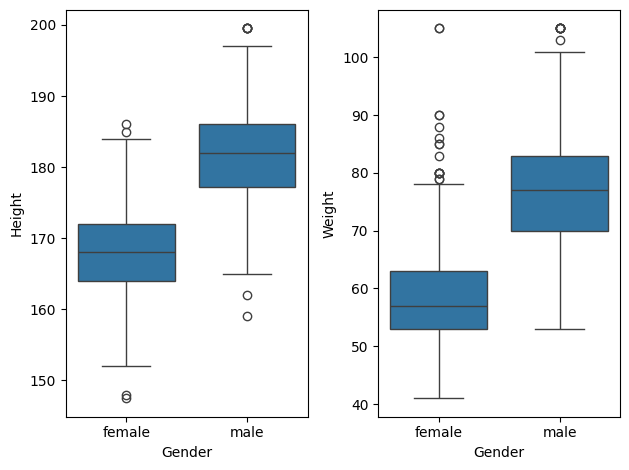

In [207]:
plt.subplot(1,2,1)
sns.boxplot(y=pre_process_df['Height'], 
            x=pre_process_df['Gender'])
plt.subplot(1,2,2)
sns.boxplot(y=pre_process_df['Weight'],
            x=pre_process_df['Gender'])
plt.tight_layout()

In [208]:
# cap the outliers for gender/height combination
for poss in pre_process_df['Gender'].unique():
    BM = pre_process_df['Gender'] == poss
    wdf = pre_process_df[BM]
    Q3 = wdf['Height'].quantile(0.75)
    Q1 = wdf['Height'].quantile(0.25)
    IQR = Q3-Q1
    
    lower_cap = Q1-IQR*1.5
    upper_cap = Q3+IQR*1.5
    
    BM = wdf['Height']>upper_cap
    pre_process_df.loc[wdf[BM].index,'Height'] = upper_cap
    
    BM = wdf['Height']<lower_cap
    pre_process_df.loc[wdf[BM].index,'Height'] = lower_cap

In [210]:
# cap the outliers for the gender/weight combination
for poss in pre_process_df['Gender'].unique():
    BM = pre_process_df['Gender'] == poss
    wdf = pre_process_df[BM]
    Q3 = wdf['Weight'].quantile(0.75)
    Q1 = wdf['Weight'].quantile(0.25)
    IQR = Q3-Q1
    
    lower_cap = Q1-IQR*1.5
    upper_cap = Q3+IQR*1.5
    
    BM = wdf['Weight']>upper_cap
    pre_process_df.loc[wdf[BM].index,'Weight'] = upper_cap
    
    BM = wdf['Weight']<lower_cap
    pre_process_df.loc[wdf[BM].index,'Weight'] = lower_cap

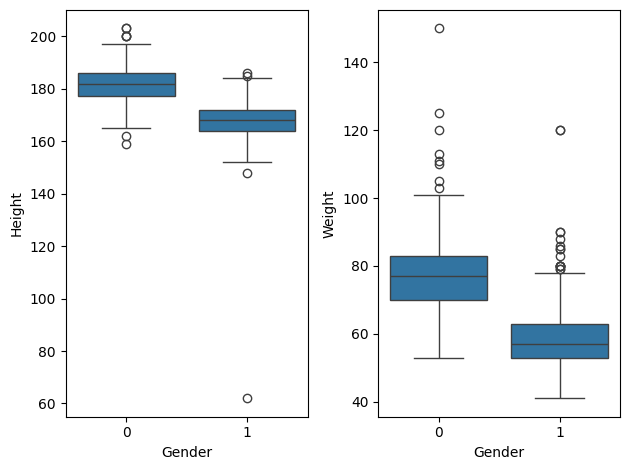

In [228]:
plt.subplot(1,2,1)
sns.boxplot(y=pre_process_df['Height'], 
            x=pre_process_df['Gender'])
plt.subplot(1,2,2)
sns.boxplot(y=pre_process_df['Weight'],
            x=pre_process_df['Gender'])
plt.tight_layout()

#### Ex3: Detecting multivariate outliers and dealing with them

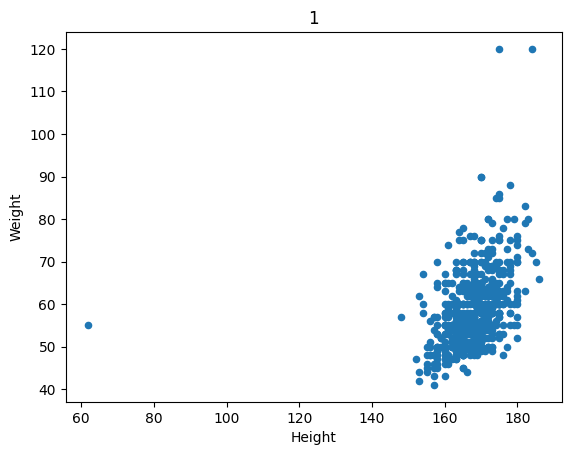

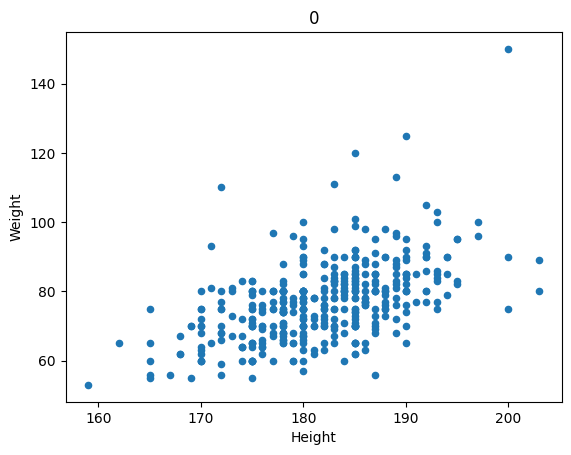

In [229]:
cat_attribute_poss = pre_process_df.Gender.unique()
for i,poss in enumerate(cat_attribute_poss):
    BM = pre_process_df.Gender == poss
    pre_process_df[BM].plot.scatter(x='Height',y='Weight')
    plt.title(poss)
    plt.show()

#### Ex3: Applying linear regression

In [230]:
pre_process_df['Gender'].replace({'male':0,'female':1},inplace=True)

In [231]:
pre_process_df.head(5)

,Weight,Height,Gender
0,48.0,163.0,1
1,58.0,163.0,1
2,67.0,176.0,1
3,59.0,172.0,1
4,59.0,170.0,1


In [232]:
from sklearn.linear_model import LinearRegression

In [233]:
# build the linear regression model
X = ['Height','Gender']
y = 'Weight'

data_X = pre_process_df[X]
data_y = pre_process_df[y]

lm = LinearRegression().fit(data_X, data_y)

In [234]:
# print the intercept and coeffiecient values
print('intercept (b0) ', lm.intercept_)
coef_names = ['b1','b2']
print(pd.DataFrame({'Predictor': data_X.columns,
                    'coefficient Name': coef_names,
                    'coefficient Value':lm.coef_}))

intercept (b0)  -32.89712733639307
  Predictor coefficient Name  coefficient Value
0    Height               b1           0.605413
1    Gender               b2          -9.880025


### Example 4

In [235]:
select_attributes = ['Weight','Height','Gender']
pre_process_df = pd.DataFrame(response_df[select_attributes])
pre_process_df.dropna(inplace=True)
pre_process_df.Gender.replace({'male':0,'female':1}, inplace=True)

In [220]:
pre_process_df.head(5)

,Weight,Height,Gender
0,48.0,163.0,1
1,58.0,163.0,1
2,67.0,176.0,1
3,59.0,172.0,1
4,59.0,170.0,1


In [221]:
pre_process_df.shape

(975, 3)

In [222]:
from sklearn.neural_network import MLPRegressor

In [223]:
X = ['Height','Gender']
y = 'Weight'

data_X = pre_process_df[X]
data_y = pre_process_df[y]

mlp = MLPRegressor(hidden_layer_sizes=5,
                   max_iter=3000).fit(data_X, data_y)

In [224]:
newData = pd.DataFrame({'Height':189.5,
                        'Gender':0},
                        index=[0])
mlp.predict(newData)

array([79.7888742])

### Example 5

In [225]:
community_df = pd.read_csv('chicago_population.csv')
community_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        77 non-null     object 
 1   population  77 non-null     int64  
 2   income      77 non-null     int64  
 3   latino      77 non-null     float64
 4   black       77 non-null     float64
 5   white       77 non-null     float64
 6   asian       77 non-null     float64
 7   other       77 non-null     float64
dtypes: float64(5), int64(2), object(1)
memory usage: 4.9+ KB


#### Ex5: Detecting univariate outliers and dealing with them

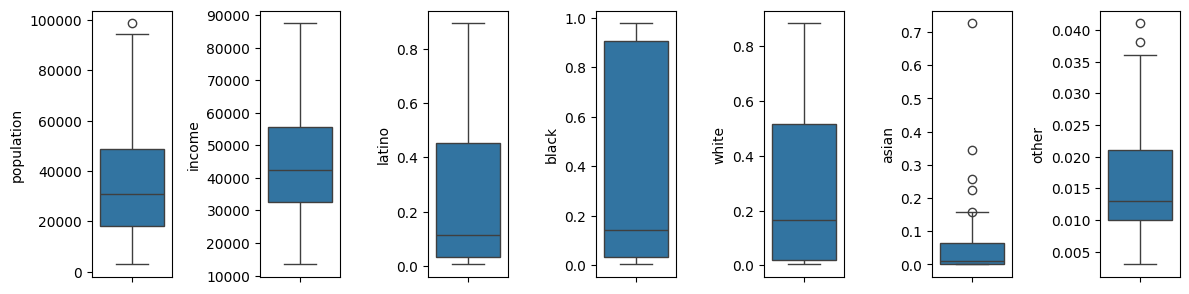

In [236]:
numerical_atts = ['population', 'income', 'latino', 'black', 'white', 'asian','other']
plt.figure(figsize=(12,3))
for i,att in enumerate(numerical_atts):
    plt.subplot(1,len(numerical_atts),i+1)
    sns.boxplot(y=community_df[att])
plt.tight_layout()
plt.show()

In [237]:
# set the outliers to the cap values
pre_process_df = community_df.set_index('name')
candidate_atts = ['population','asian','other']

for att in candidate_atts:
    Q3 = pre_process_df[att].quantile(0.75)
    Q1 = pre_process_df[att].quantile(0.25)
    IQR = Q3 - Q1

    lower_cap = Q1-IQR*1.5
    upper_cap = Q3+IQR*1.5

    BM = pre_process_df[att] < lower_cap
    candidate_index = pre_process_df[BM].index
    pre_process_df.loc[candidate_index,att] = lower_cap

    BM = pre_process_df[att] > upper_cap
    candidate_index = pre_process_df[BM].index
    pre_process_df.loc[candidate_index,att] = upper_cap

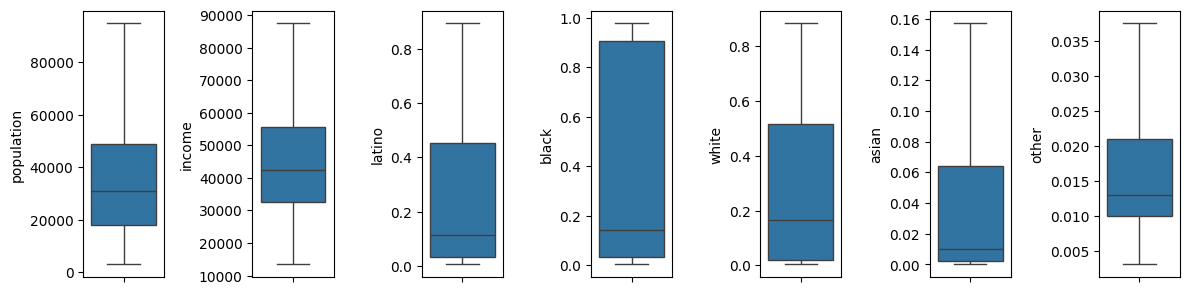

In [238]:
numerical_atts = ['population', 'income', 'latino', 'black', 'white', 'asian','other']
plt.figure(figsize=(12,3))
for i,att in enumerate(numerical_atts):
    plt.subplot(1,len(numerical_atts),i+1)
    sns.boxplot(y=pre_process_df[att])
plt.tight_layout()
plt.show()

#### Applying K-Means

In [240]:
from sklearn.cluster import KMeans
dimensions = ['population','income','latino','black','white',
             'asian','other']
Xs = pre_process_df[dimensions]
Xs = (Xs - Xs.min())/(Xs.max()-Xs.min())
kmeans = KMeans(n_clusters=5)
kmeans.fit(Xs)

KMeans(n_clusters=5)

In [243]:
for i in range(5):
    BM = kmeans.labels_==i
    print('Cluster {}:{}'.format(i, pre_process_df[BM].index.values))

Cluster 0:['Rogers Park' 'West Ridge' 'Uptown' 'Lincoln Square' 'North Park'
 'Albany Park' 'Near West Side' 'Loop' 'Near South Side' 'Armour Square'
 'Douglas' 'Hyde Park' 'McKinley Park' 'Bridgeport' 'Edgewater']
Cluster 1:['Austin' 'West Garfield Park' 'East Garfield Park' 'North Lawndale'
 'Oakland' 'Fuller Park' 'Grand Boulevard' 'Kenwood' 'Washington Park'
 'Woodlawn' 'South Shore' 'Chatham' 'Avalon Park' 'South Chicago'
 'Burnside' 'Calumet Heights' 'Roseland' 'Pullman' 'South Deering'
 'West Pullman' 'Riverdale' 'West Englewood' 'Englewood'
 'Greater Grand Crossing' 'Auburn Gresham' 'Washington Heights'
 'Morgan Park']
Cluster 2:['Portage Park' 'Irving Park' 'Montclare' 'Avondale' 'Logan Square'
 'Hegewisch' 'Garfield Ridge' 'Clearing' 'Ashburn']
Cluster 3:['North Center' 'Lake View' 'Lincoln Park' 'Near North Side' 'Edison Park'
 'Norwood Park' 'Jefferson Park' 'Forest Glen' 'Dunning' 'West Town'
 'Beverly' 'Mount Greenwood' "O'Hare"]
Cluster 4:['Belmont Cragin' 'Hermosa' 'Hum

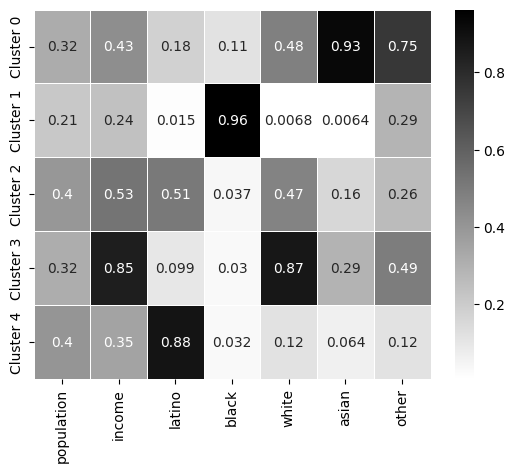

In [246]:
clusters = ['Cluster {}'.format(i) for i in range(5)]

Centroids = pd.DataFrame(0.0, index=clusters,
                         columns = Xs.columns)
for i,clst in enumerate(clusters):
    BM = kmeans.labels_ == i
    Centroids.loc[clst] = Xs[BM].median(axis=0)

sns.heatmap(Centroids, linewidths=0.5, annot=True,
            cmap='binary')
plt.show()

## Errors

In [251]:
hour_df = pd.read_excel('CustomerEnteries.xlsx')
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         495 non-null    datetime64[ns]
 1   Time         495 non-null    int64         
 2   N_Customers  495 non-null    int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 11.7 KB


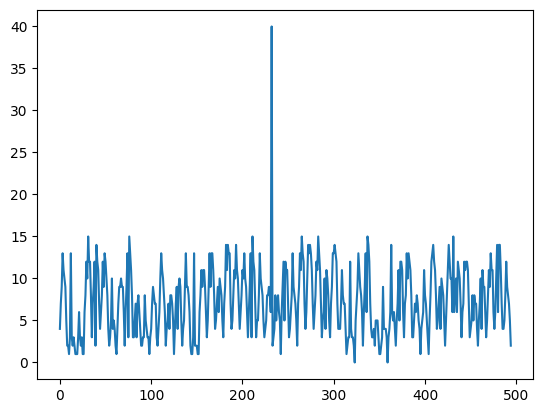

In [252]:
hour_df.N_Customers.plot()
plt.show()

In [256]:
hour_df[hour_df.N_Customers>20]

,Date,Time,N_Customers
232,2020-10-26,16,40


In [259]:
err_index = hour_df[hour_df.N_Customers>20].index

In [272]:
# Set the outlier to NaN
hour_df.loc[err_index[0],'N_Customers']=np.nan

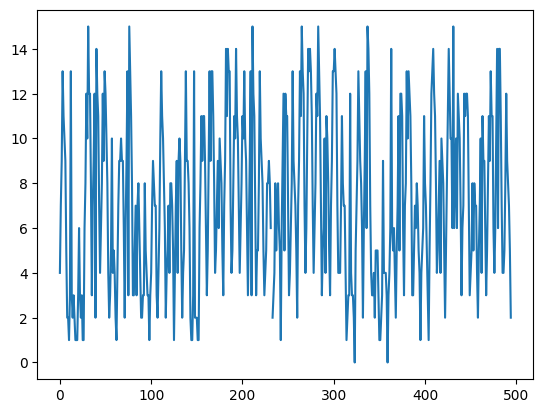

In [274]:
hour_df.N_Customers.plot()
plt.show()

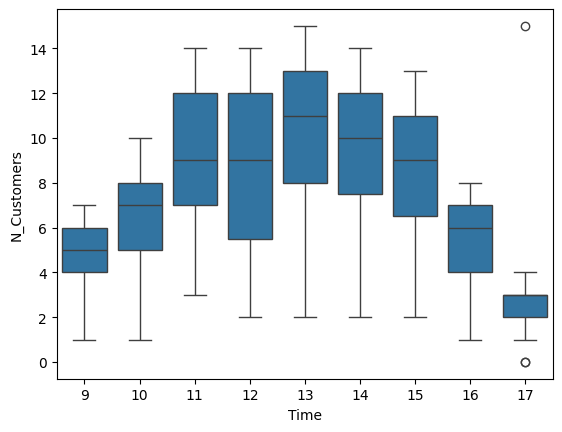

In [275]:
sns.boxplot(y=hour_df.N_Customers,x=hour_df.Time)
plt.show()

In [276]:
hour_df.query("Time==17 and N_Customers>12")

,Date,Time,N_Customers
431,2020-11-17,17,15.0


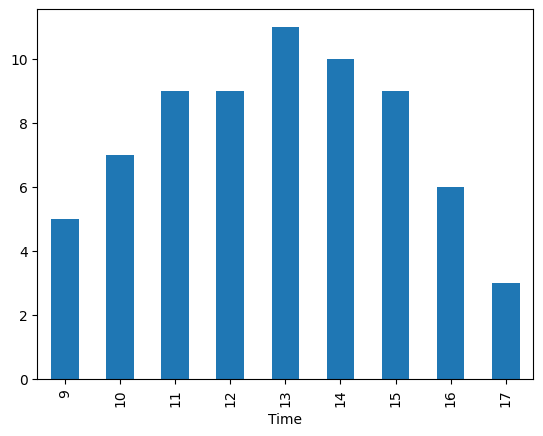

In [277]:
hour_df.groupby('Time').N_Customers.median().plot.bar()
plt.show()